In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.ensemble import RandomForestClassifier


In [ ]:
uploaded = files.upload()

Saving k5r1a2_final.xlsx to k5r1a2_final.xlsx


In [ ]:
df_private = pd.read_excel('k5r1a2_final.xlsx')
df_private.head()

,GioiTinh,TienSuYKhoa,ChamNoi,CungNhac,CoLap,ChoiCamGiac_VanDong,ChoiChucNang,ChoiKetHop,ChoiGiaVo,HanhViLapLai,KyNangGiaoTiepSom,ChoiLuanPhien,BatChuoc,SaiViec,PhanUngTenGoi,DiNhonChan,ChiTro,ChuYLienKet,TiepXucMat,TargetBinary
0,1,0,0,0,0,0.0,0.0,0.0,0.5,0,0.0,0.0,0.0,0.0,0.0,0,0.5,0.0,0.0,1
1,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.5,0.0,1
2,1,1,0,0,0,0.0,1.0,0.0,0.5,1,0.5,0.0,0.0,0.0,0.0,0,1.0,0.5,0.5,1
3,0,0,1,0,0,0.0,0.0,0.0,0.0,0,0.5,0.0,0.0,0.0,0.0,0,1.0,0.5,0.0,1
4,1,0,0,0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.5,0.5,1


# MÃ HÓA DF_PRIVATE

In [ ]:
# Liệt kê tên các cột
print(df_private.columns.tolist())
rows, cols = df_private.shape
print(f"Số hàng: {rows}, Số cột: {cols}")

['GioiTinh', 'TienSuYKhoa', 'ChamNoi', 'CungNhac', 'CoLap', 'ChoiCamGiac_VanDong', 'ChoiChucNang', 'ChoiKetHop', 'ChoiGiaVo', 'HanhViLapLai', 'KyNangGiaoTiepSom', 'ChoiLuanPhien', 'BatChuoc', 'SaiViec', 'PhanUngTenGoi', 'DiNhonChan', 'ChiTro', 'ChuYLienKet', 'TiepXucMat', 'TargetBinary']
Số hàng: 864, Số cột: 20


In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(df_private)
if p < 0.05:
    print("Không phân phối chuẩn")

Không phân phối chuẩn


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 17280.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
for i, col in enumerate(df_private.columns):
    print(f"Vị trí {i}: {col}")

Vị trí 0: GioiTinh
Vị trí 1: TienSuYKhoa
Vị trí 2: ChamNoi
Vị trí 3: CungNhac
Vị trí 4: CoLap
Vị trí 5: ChoiCamGiac_VanDong
Vị trí 6: ChoiChucNang
Vị trí 7: ChoiKetHop
Vị trí 8: ChoiGiaVo
Vị trí 9: HanhViLapLai
Vị trí 10: KyNangGiaoTiepSom
Vị trí 11: ChoiLuanPhien
Vị trí 12: BatChuoc
Vị trí 13: SaiViec
Vị trí 14: PhanUngTenGoi
Vị trí 15: DiNhonChan
Vị trí 16: ChiTro
Vị trí 17: ChuYLienKet
Vị trí 18: TiepXucMat
Vị trí 19: TargetBinary


Hoán vị tầm quan trọng của tính năng là một kỹ thuật để tính điểm quan trọng tương đối độc lập với mô hình được sử dụng. KNN

In [ ]:
X = df_private.iloc[:, 0:19]
y = df_private.iloc[:, 19]

# MÃ HÓA

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Xác định cột
numerical_ix = X.select_dtypes(include=['int64', 'float64']).columns
categorical_ix = X.select_dtypes(include=['object', 'bool']).columns

# 2. Fit riêng OneHotEncoder để lấy tên
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X[categorical_ix])
cat_feature_names = ohe.get_feature_names_out(categorical_ix)

# 3. Xây dựng ColumnTransformer dùng lại ohe đã fit
preprocessor = ColumnTransformer(transformers=[
    ('cat', ohe, categorical_ix),
    ('num', MinMaxScaler(), numerical_ix)
])

# 4. Fit + transform toàn bộ
X_transformed = preprocessor.fit_transform(X)

# 5. Kết hợp tên cột đầy đủ
all_columns = list(cat_feature_names) + list(numerical_ix)

# 6. Tạo DataFrame kết quả
df_transformed = pd.DataFrame(X_transformed, columns=all_columns)

# 7. In kết quả
print(df_transformed.head())


   GioiTinh  TienSuYKhoa  ChamNoi  CungNhac  CoLap  ChoiCamGiac_VanDong  \
0       1.0          0.0      0.0       0.0    0.0                  0.0   
1       0.0          0.0      0.0       0.0    0.0                  0.0   
2       1.0          1.0      0.0       0.0    0.0                  0.0   
3       0.0          0.0      1.0       0.0    0.0                  0.0   
4       1.0          0.0      0.0       0.0    0.0                  0.0   

   ChoiChucNang  ChoiKetHop  ChoiGiaVo  HanhViLapLai  KyNangGiaoTiepSom  \
0           0.0         0.0        0.5           0.0                0.0   
1           0.0         0.0        0.0           0.0                0.0   
2           1.0         0.0        0.5           1.0                0.5   
3           0.0         0.0        0.0           0.0                0.5   
4           0.0         0.0        0.0           0.0                0.0   

   ChoiLuanPhien  BatChuoc  SaiViec  PhanUngTenGoi  DiNhonChan  ChiTro  \
0            0.0       0

In [ ]:
# Giả sử y là Series gốc chứa TargetBinary
df_private = df_transformed.copy()
df_private['TargetBinary'] = y.loc[df_transformed.index].values

# Xem kết quả
print(df_private.head())

   GioiTinh  TienSuYKhoa  ChamNoi  CungNhac  CoLap  ChoiCamGiac_VanDong  \
0       1.0          0.0      0.0       0.0    0.0                  0.0   
1       0.0          0.0      0.0       0.0    0.0                  0.0   
2       1.0          1.0      0.0       0.0    0.0                  0.0   
3       0.0          0.0      1.0       0.0    0.0                  0.0   
4       1.0          0.0      0.0       0.0    0.0                  0.0   

   ChoiChucNang  ChoiKetHop  ChoiGiaVo  HanhViLapLai  KyNangGiaoTiepSom  \
0           0.0         0.0        0.5           0.0                0.0   
1           0.0         0.0        0.0           0.0                0.0   
2           1.0         0.0        0.5           1.0                0.5   
3           0.0         0.0        0.0           0.0                0.5   
4           0.0         0.0        0.0           0.0                0.0   

   ChoiLuanPhien  BatChuoc  SaiViec  PhanUngTenGoi  DiNhonChan  ChiTro  \
0            0.0       0

In [ ]:
def round_to_three_levels(x):
    if x < 0.25:
        return 0
    elif x < 0.75:
        return 0.5
    else:
        return 1

df_private = df_private.applymap(round_to_three_levels)

<ipython-input-9-3b0b949f3cad>:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_private = df_private.applymap(round_to_three_levels)


In [ ]:
df_private['TargetBinary'].value_counts()

,count
TargetBinary,
1,489
0,375


# Mô hình hóa dữ liệu

In [ ]:
from scipy.stats import kendalltau
import pandas as pd
# 2. Kendall's Tau (Tương quan thứ bậc Kendall) giữa features và target
results = []

for col in df_private.columns[:-1]:  # Trừ cột TargetBinary
    corr, p = kendalltau(df_private[col], df_private['TargetBinary'])
    strength = ""
    if p < 0.05:
        if abs(corr) >= 0.3:
            strength = "Tương quan mạnh"
        elif abs(corr) >= 0.2:
            strength = "Tương quan vừa"
        else:
            strength = "Tương quan yếu"
        significance = "✅ Có ý nghĩa thống kê"
    else:
        strength = "-"
        significance = "❌ Không có ý nghĩa"

    results.append({
        "Đặc trưng": col,
        "Kendall's Tau": round(corr, 3) if corr is not None else None,
        "p-value": round(p, 3) if p is not None else None,
        "Mức độ tương quan": strength,
        "Ý nghĩa thống kê": significance
    })

# Chuyển kết quả thành DataFrame
df_kendall_analysis = pd.DataFrame(results)

# In toàn bộ kết quả
print(df_kendall_analysis.to_string(index=False))


          Đặc trưng  Kendall's Tau  p-value Mức độ tương quan      Ý nghĩa thống kê
           GioiTinh          0.157    0.000    Tương quan yếu ✅ Có ý nghĩa thống kê
        TienSuYKhoa          0.160    0.000    Tương quan yếu ✅ Có ý nghĩa thống kê
            ChamNoi          0.824    0.000   Tương quan mạnh ✅ Có ý nghĩa thống kê
           CungNhac          0.364    0.000   Tương quan mạnh ✅ Có ý nghĩa thống kê
              CoLap          0.563    0.000   Tương quan mạnh ✅ Có ý nghĩa thống kê
ChoiCamGiac_VanDong          0.065    0.054                 -    ❌ Không có ý nghĩa
       ChoiChucNang          0.037    0.256                 -    ❌ Không có ý nghĩa
         ChoiKetHop          0.099    0.003    Tương quan yếu ✅ Có ý nghĩa thống kê
          ChoiGiaVo          0.020    0.537                 -    ❌ Không có ý nghĩa
       HanhViLapLai          0.303    0.000   Tương quan mạnh ✅ Có ý nghĩa thống kê
  KyNangGiaoTiepSom          0.714    0.000   Tương quan mạnh ✅ Có ý nghĩa t

In [ ]:
df_private = df_private.drop(columns=['ChoiGiaVo', 'ChoiCamGiac_VanDong', 'ChoiChucNang' ])

In [ ]:
for i, col in enumerate(df_private.columns):
    print(f"Vị trí {i}: {col}")

Vị trí 0: GioiTinh
Vị trí 1: TienSuYKhoa
Vị trí 2: ChamNoi
Vị trí 3: CungNhac
Vị trí 4: CoLap
Vị trí 5: ChoiKetHop
Vị trí 6: HanhViLapLai
Vị trí 7: KyNangGiaoTiepSom
Vị trí 8: ChoiLuanPhien
Vị trí 9: BatChuoc
Vị trí 10: SaiViec
Vị trí 11: PhanUngTenGoi
Vị trí 12: DiNhonChan
Vị trí 13: ChiTro
Vị trí 14: ChuYLienKet
Vị trí 15: TiepXucMat
Vị trí 16: TargetBinary


## Biểu đồ histogram (biểu đồ tần suất) kèm đường KDE (đường mật độ), dùng để phân tích phân phối giá trị của các đặc trưng đầu vào

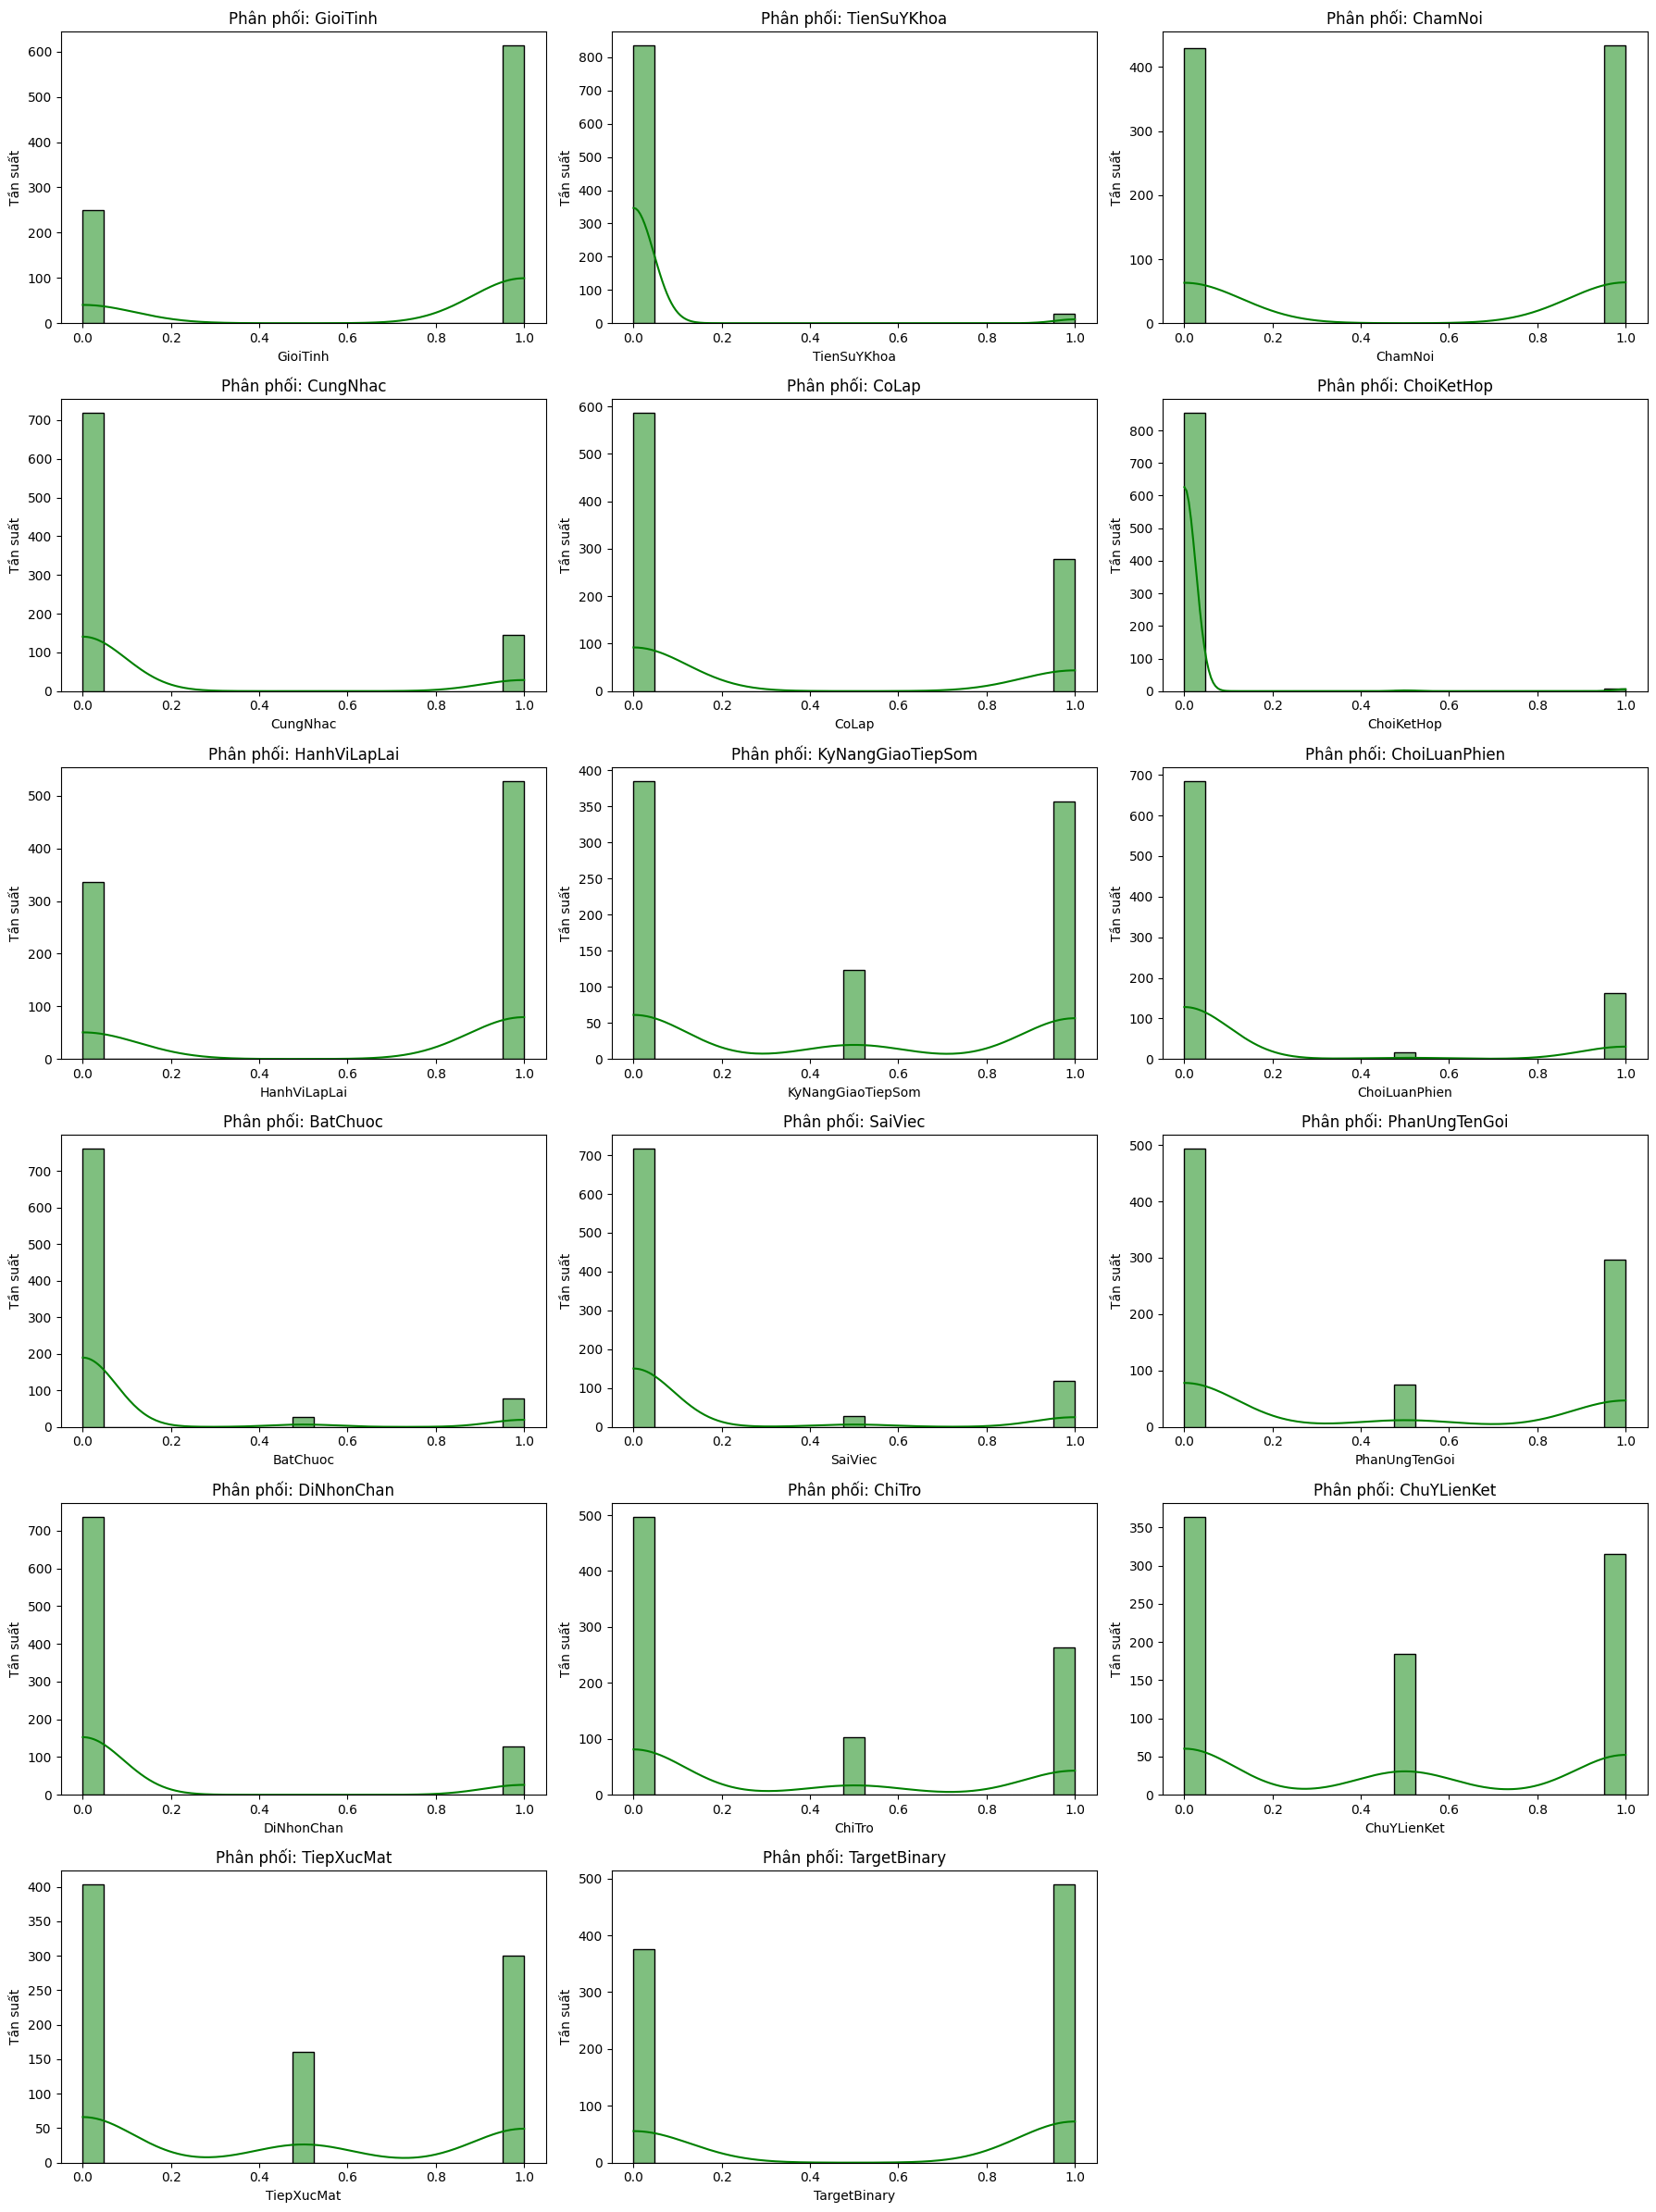

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Giả sử df_private là DataFrame với ít nhất 19 cột
feature_cols = df_private.columns[:19]
n_features = len(feature_cols)

# Tính toán số hàng và cột cho lưới (ví dụ 3 cột)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# Tạo lưới subplot phù hợp
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Vẽ từng histogram
for i, feature in enumerate(feature_cols):
    sns.histplot(df_private[feature], bins=21, kde=True, color='green', ax=axes[i])
    axes[i].set_title(f'Phân phối: {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Tần suất')

# Tắt các subplot thừa nếu có
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


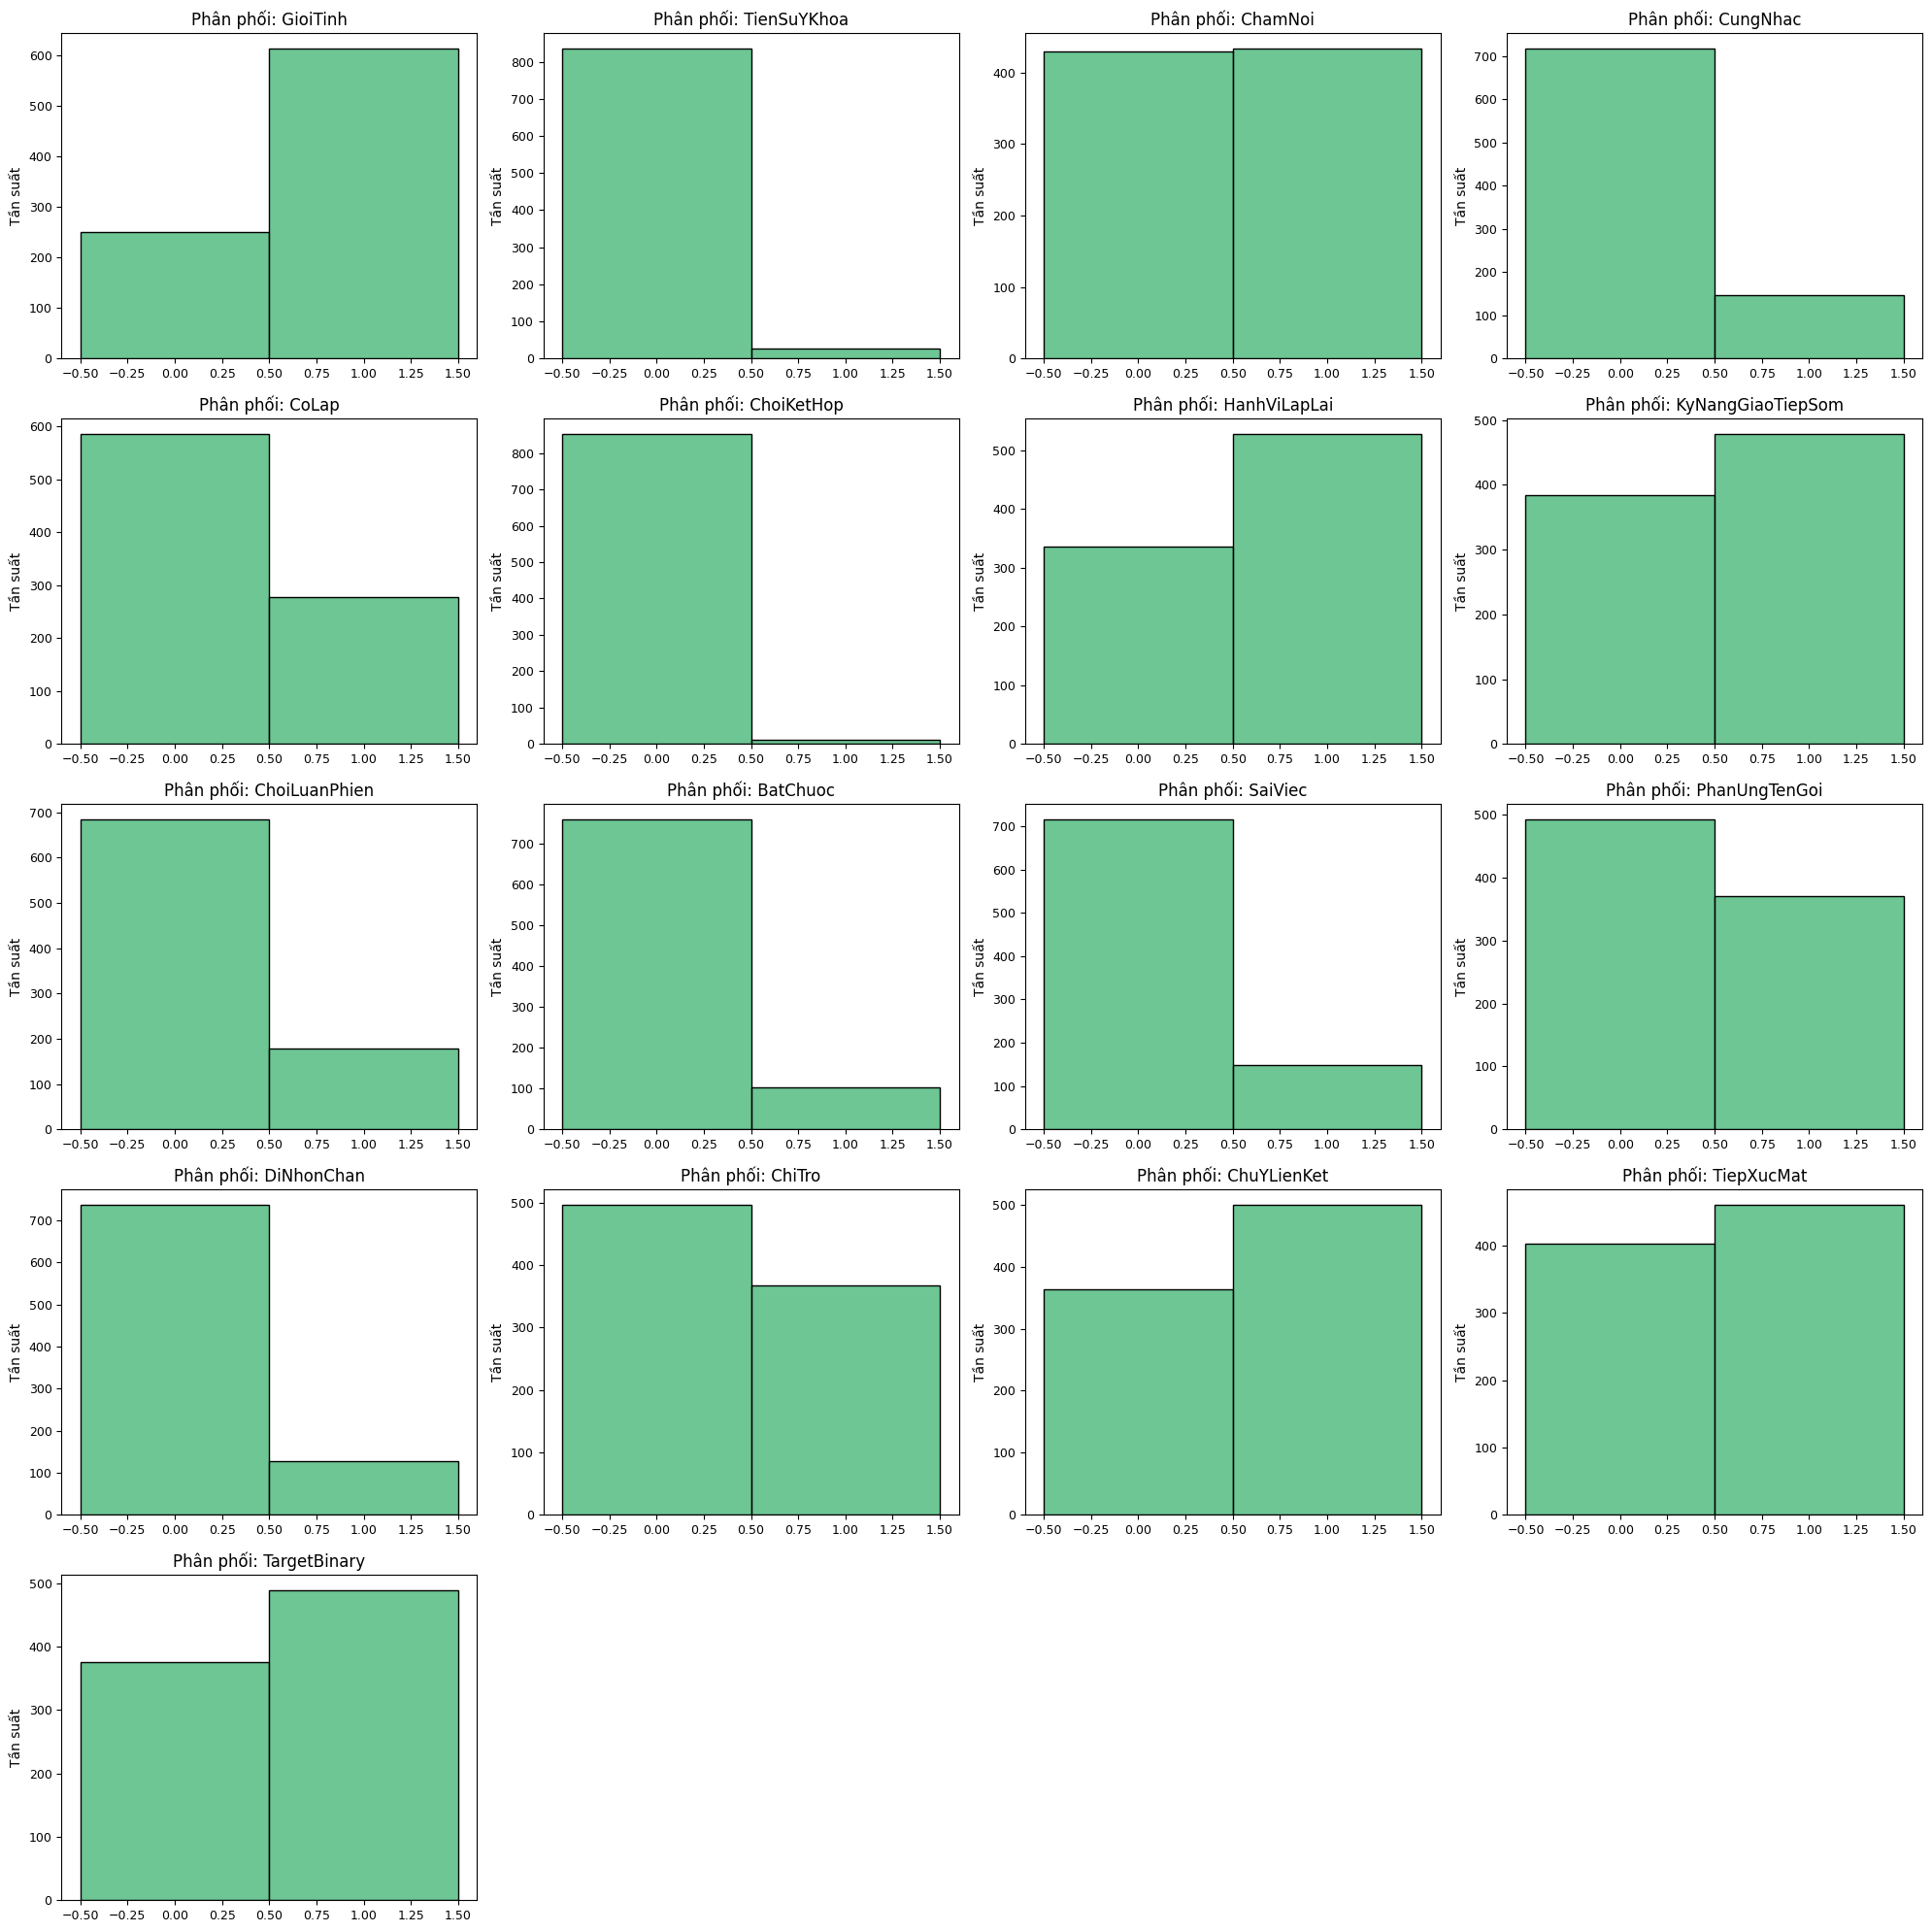

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Kiểm tra phân phối, lệch lớp Histogram


# Lấy các cột đặc trưng, loại trừ cột TargetBinary nếu1 muốn
feature_cols = df_private.columns[:19]  # bỏ TargetBinary nếu cần vẽ riêng

# Tạo lưới 5 hàng x 4 cột (20 biểu đồ), dư ra 1 slot nếu sau này thêm 1 cột
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()  # Flatten để dễ lặp

for i, feature in enumerate(feature_cols):
    sns.histplot(df_private[feature], bins=range(0, 5), discrete=True, color='mediumseagreen', ax=axes[i])
    axes[i].set_title(f'Phân phối: {feature}', fontsize=12)
    axes[i].set_xlabel('', fontsize=10)
    axes[i].set_ylabel('Tần suất', fontsize=10)
    axes[i].tick_params(axis='x', labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

# Xoá các ô dư không sử dụng
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

# Căn chỉnh lại layout
plt.tight_layout()
plt.show()


In [ ]:
df_private = df_private.drop(columns=['TienSuYKhoa', 'ChoiKetHop'])

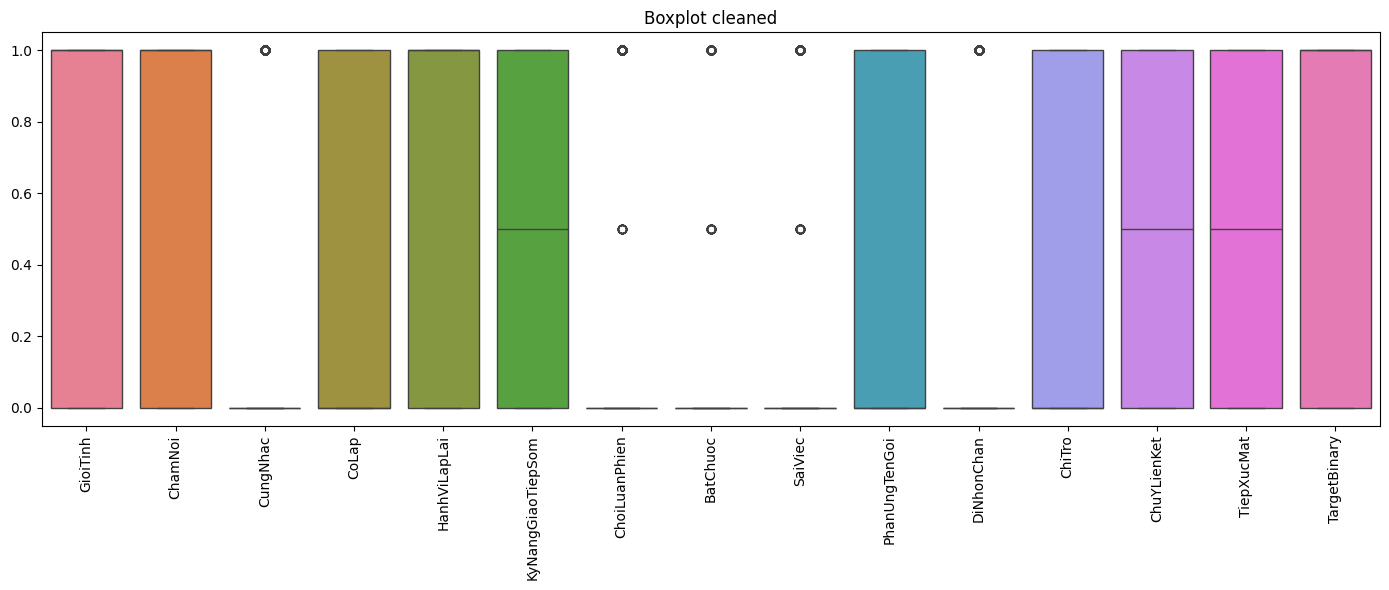

In [ ]:
selected_columns = df_private.columns[:19]

# 3. Vẽ boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_private[selected_columns])
plt.xticks(rotation=90)
plt.title("Boxplot cleaned")
plt.tight_layout()
plt.show()

1. GioiTinh, ChamNoi, CoLap, HanhViLapLai, PhanUngTenGoi, ChiTro: Có giá trị gần như chỉ ở 0 và 1	Đây là các biến nhị phân rõ rệt
2. KyNangGiaoTiepSom, ChuYLienKet: Có trung vị ở 0.5, giá trị phân bố đều hơn	Đây là biến có phân phối đa mức (0, 0.5, 1)
3. ChoiLuanPhien, BatChuoc, SaiViec, DiNhonChan, CungNhac	Gần như toàn giá trị thấp, có outlier ở 1: Rất mất cân bằng, hầu như là 0 → có thể không có nhiều giá trị phân biệt

Cần bắt các trường hợp outline nên không cần loại trừ các cột này

## Biểu đồ cột trung bình (mean barplot), thể hiện giá trị trung bình của các biến theo hai nhóm TargetBinary (0 và 1).

<ipython-input-103-c91a4a190719>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], estimator=np.mean, ci=None)
<ipython-input-103-c91a4a190719>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], estimator=np.mean, ci=None)
<ipython-input-103-c91a4a190719>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], estimator=np.mean, ci=None)
<ipython-input-103-c91a4a190719>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], estimator=np.mean, ci=None)
<ipython-input-103-c91a4a190719>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `err

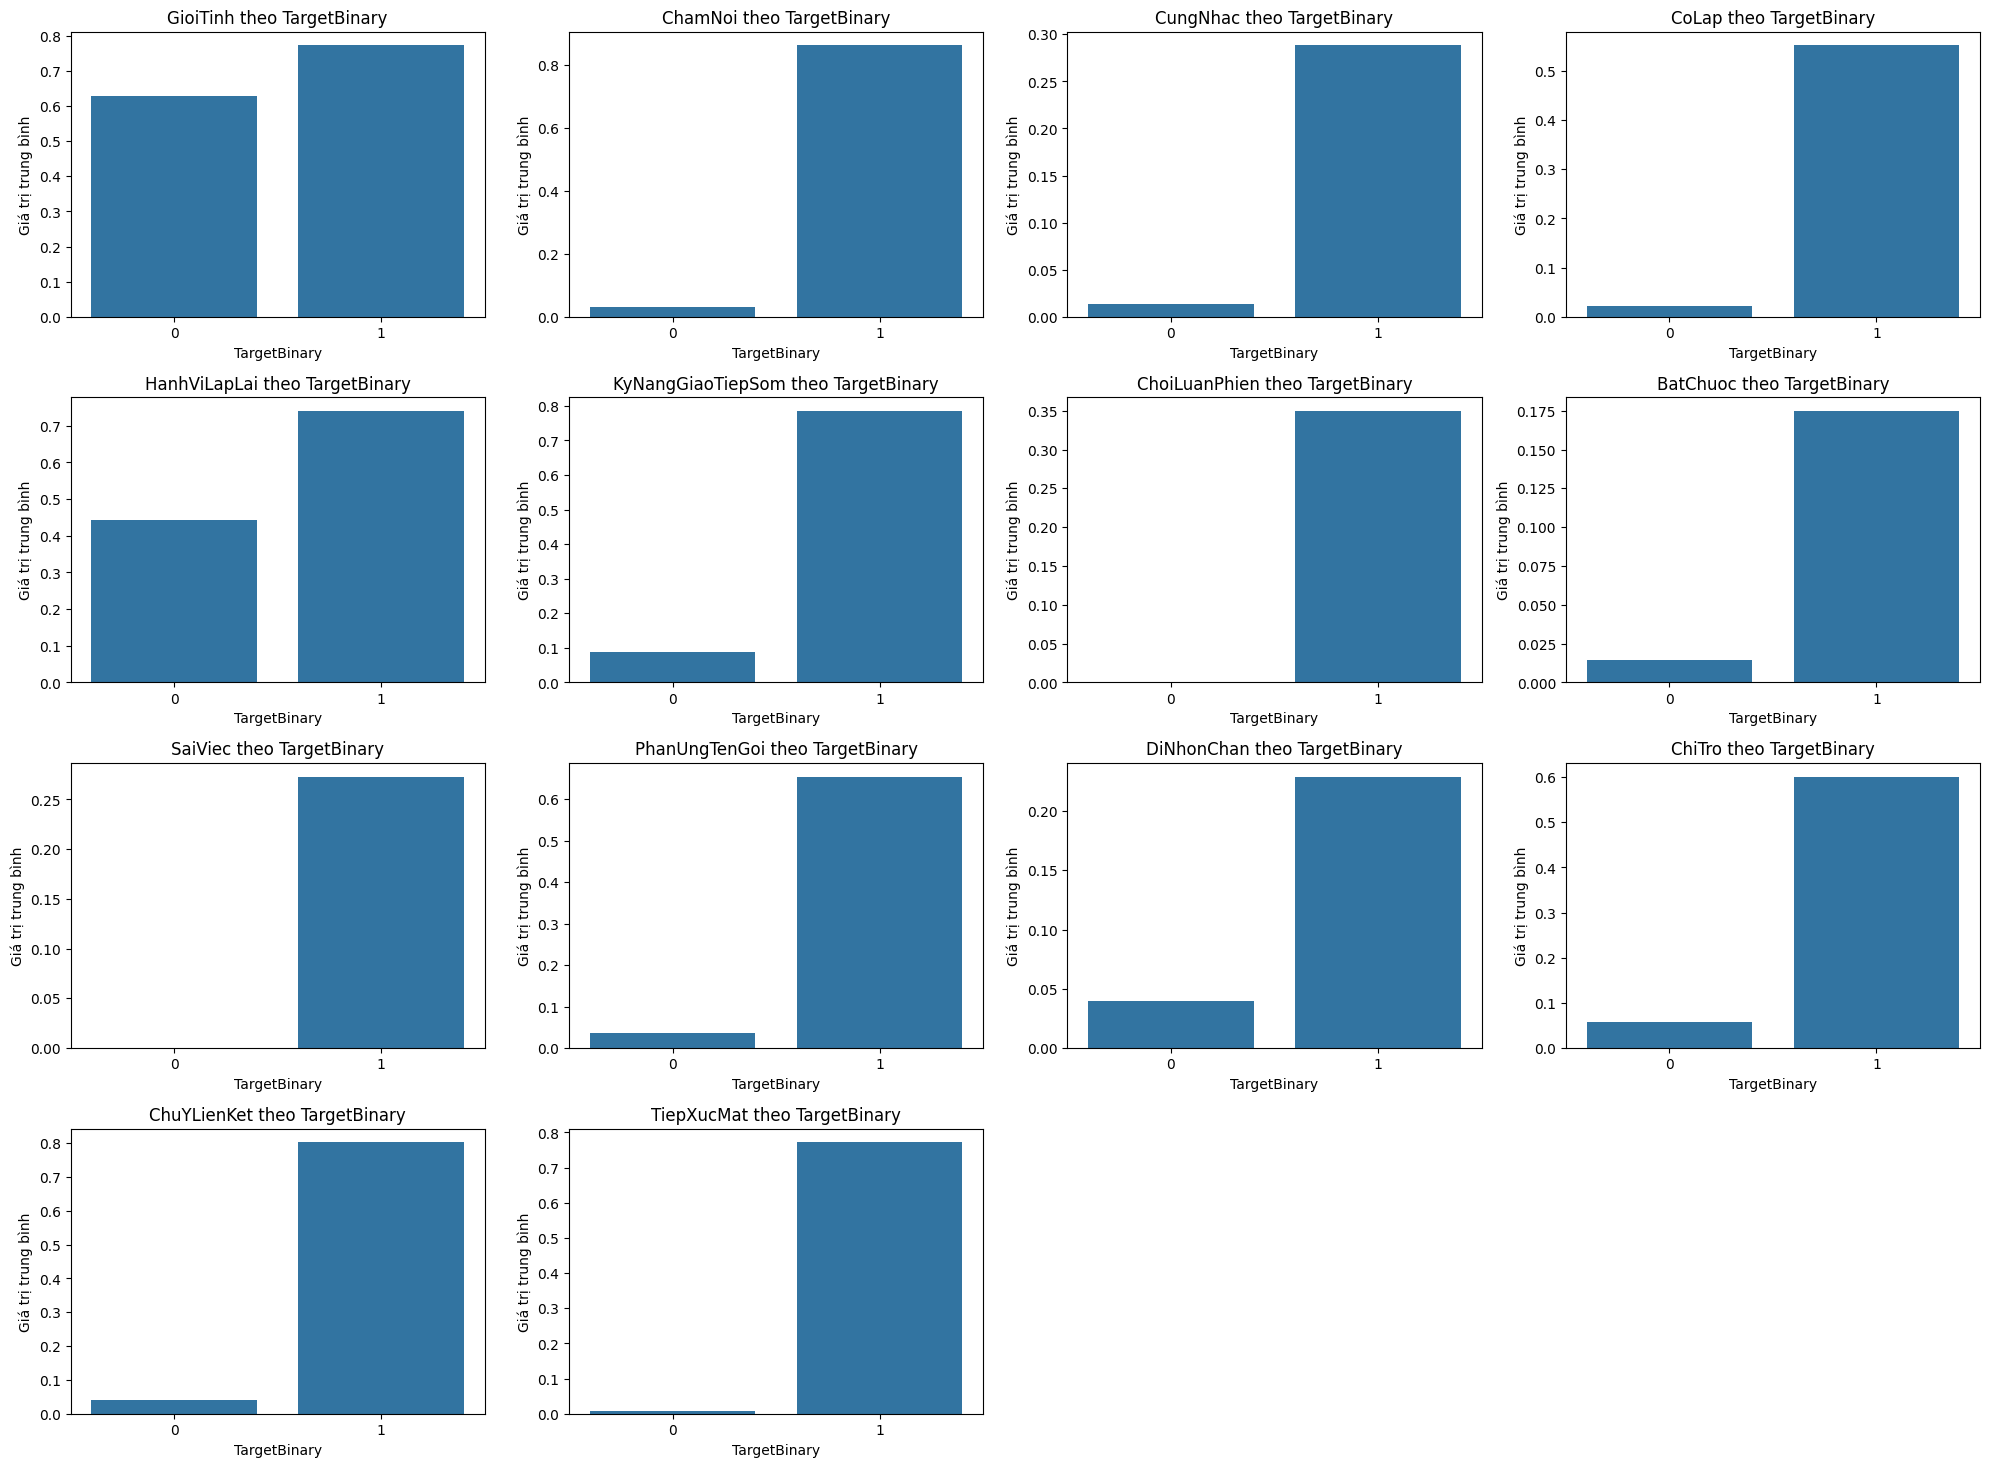

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# 4. Barplot giữa các đặc trưng và target


# Lấy danh sách cột đặc trưng (trừ TargetBinary)
feature_cols = [col for col in df_private.columns if col != 'TargetBinary']

# Tạo lưới 5x4 để vẽ tối đa 20 cột
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 18))
axes = axes.flatten()

# Vẽ barplot cho từng cột theo nhóm TargetBinary
for i, col in enumerate(feature_cols):
    sns.barplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], estimator=np.mean, ci=None)
    axes[i].set_title(f"{col} theo TargetBinary")
    axes[i].set_xlabel("TargetBinary")
    axes[i].set_ylabel("Giá trị trung bình")

# Xoá các ô dư nếu feature < 20
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


BatChuoc: Gần như toàn 0 (0.02 vs 0.15);
SaiViec: Rất thấp (0.1 vs 0.3)

In [ ]:
df_private = df_private.drop(columns=['BatChuoc', 'SaiViec'])

<ipython-input-106-7dda5bace061>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], inner='quartile', palette='Set2')
<ipython-input-106-7dda5bace061>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], inner='quartile', palette='Set2')
<ipython-input-106-7dda5bace061>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], inner='quartile', palette='Set2')
<ipython-input-106-7dda5b

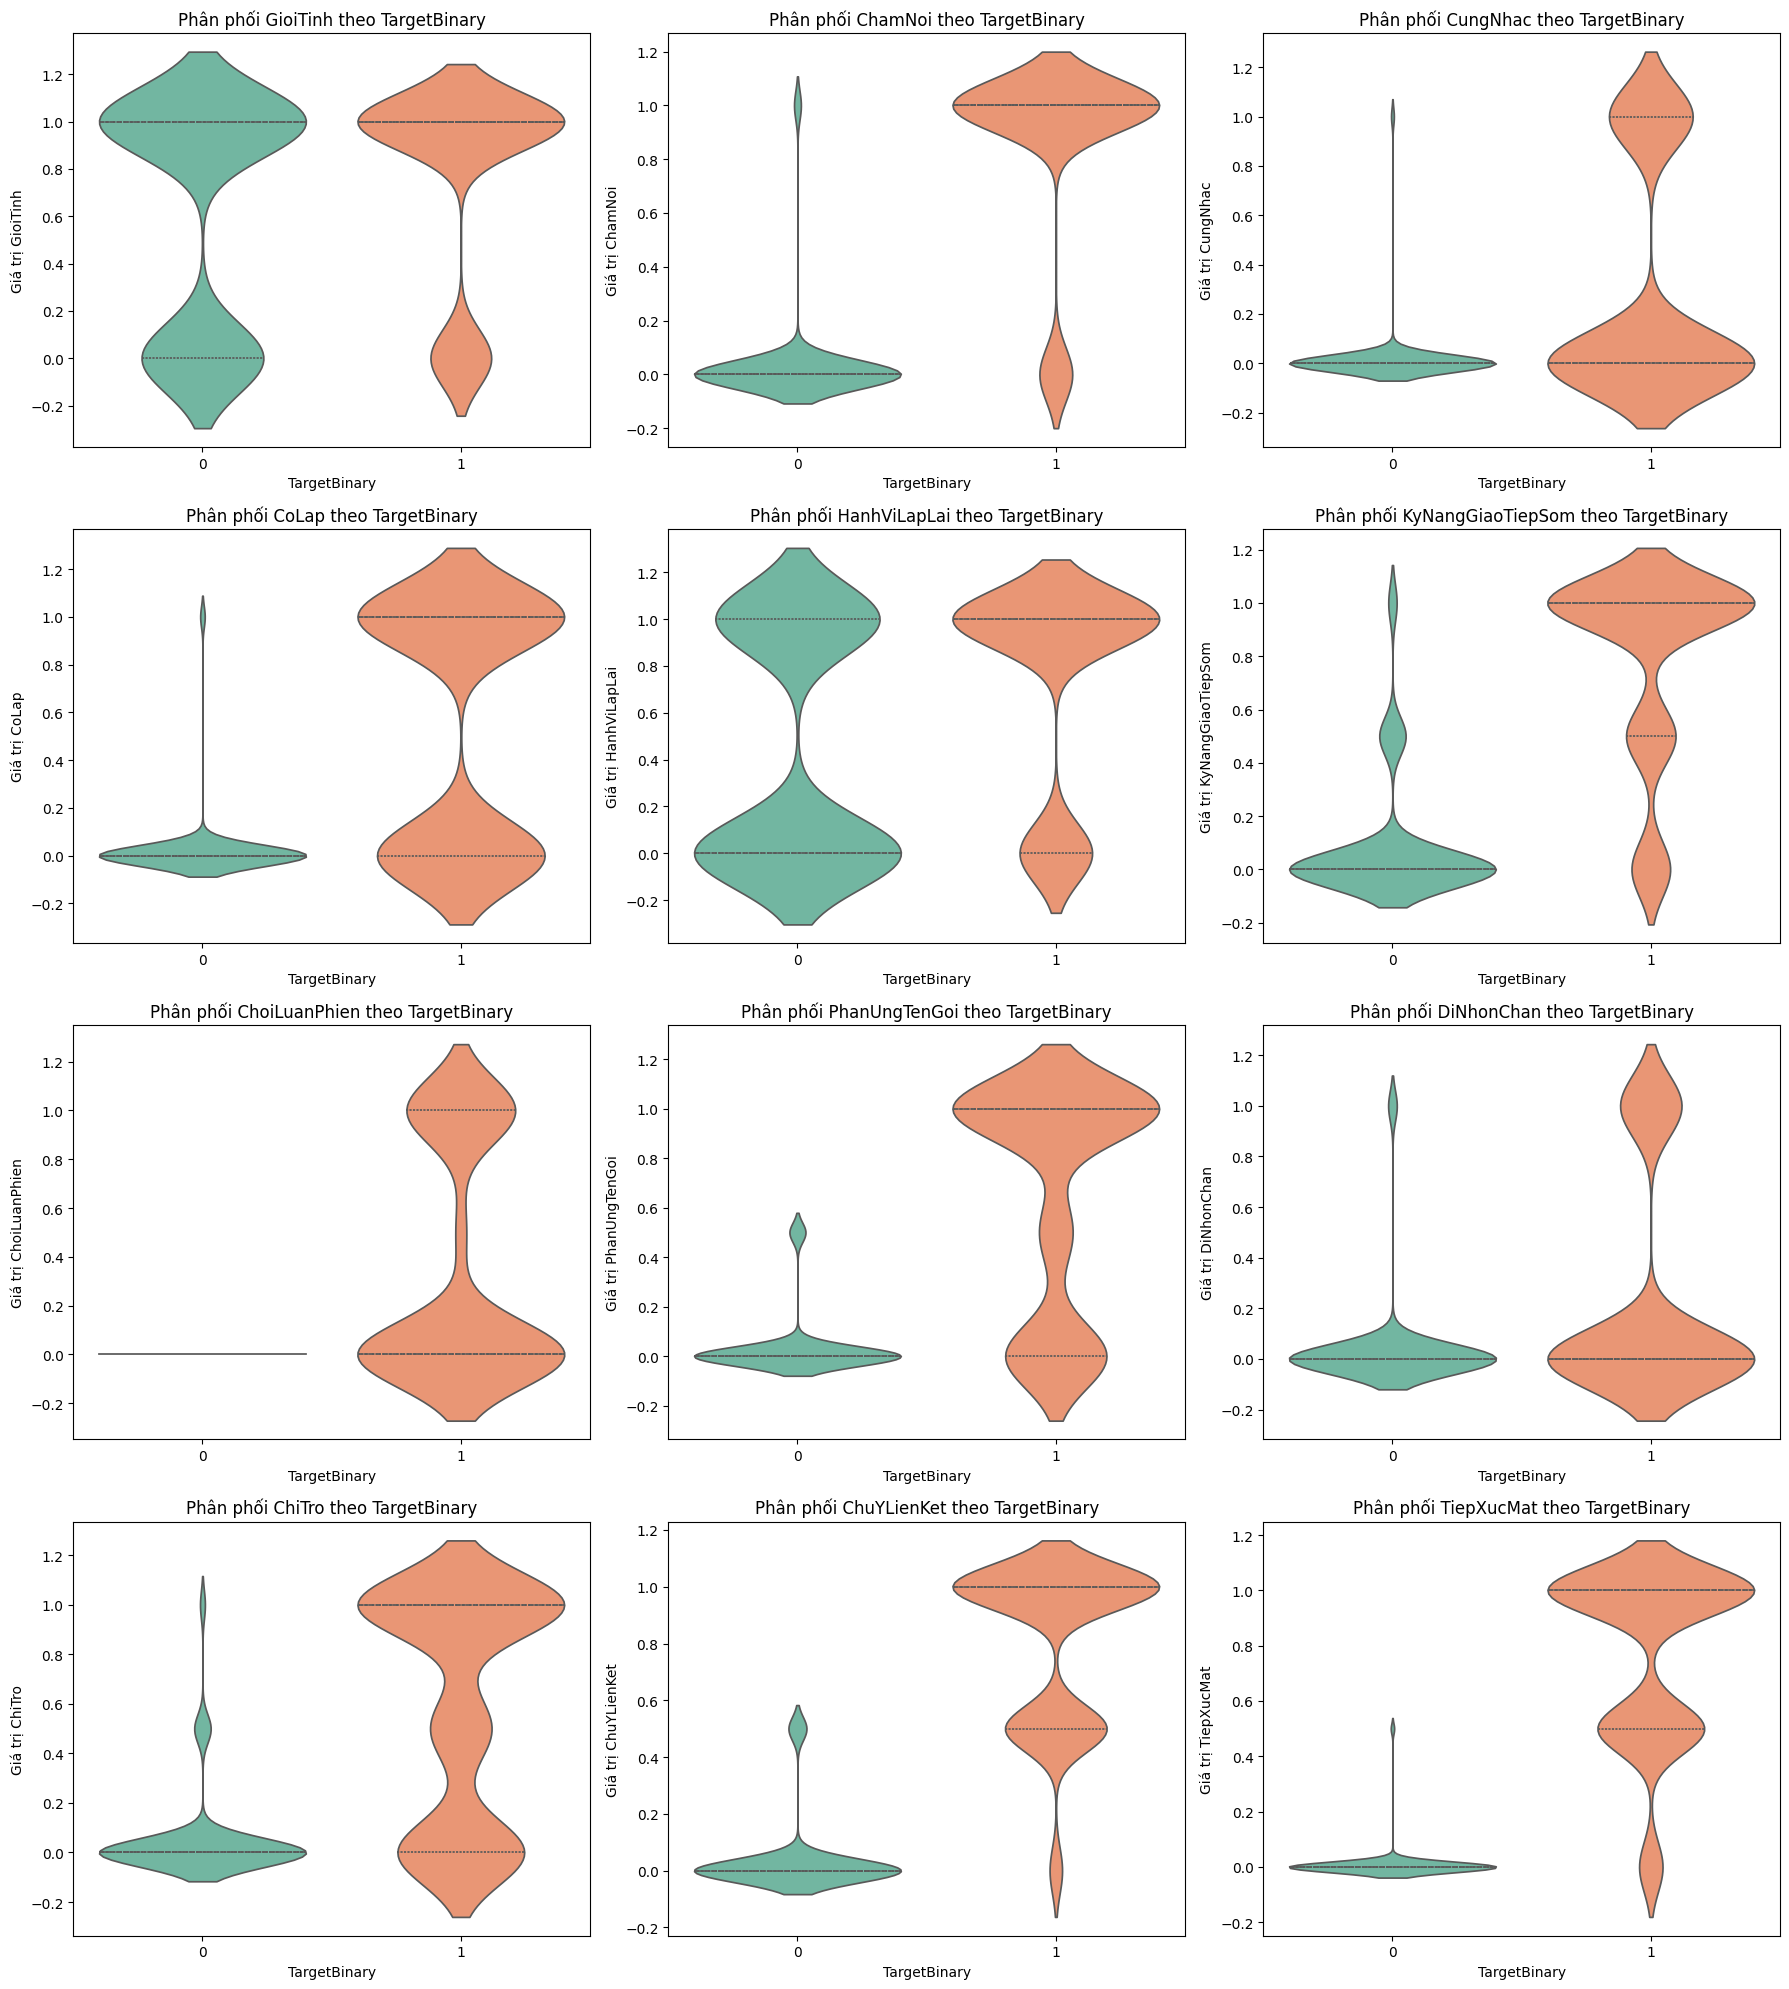

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Violin plot

# Lấy danh sách cột đặc trưng (trừ TargetBinary)
feature_cols = [col for col in df_private.columns if col != 'TargetBinary']

# Thiết lập lưới để hiển thị tất cả violin plots cho các đặc trưng
num_features = len(feature_cols)
rows = (num_features + 2) // 3  # 3 cột mỗi hàng
fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
axes = axes.flatten()

# Vẽ từng biểu đồ violin
for i, col in enumerate(feature_cols):
    sns.violinplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], inner='quartile', palette='Set2')
    axes[i].set_title(f'Phân phối {col} theo TargetBinary')
    axes[i].set_xlabel('TargetBinary')
    axes[i].set_ylabel(f'Giá trị {col}')

# Ẩn các ô dư nếu số cột không chia hết cho 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



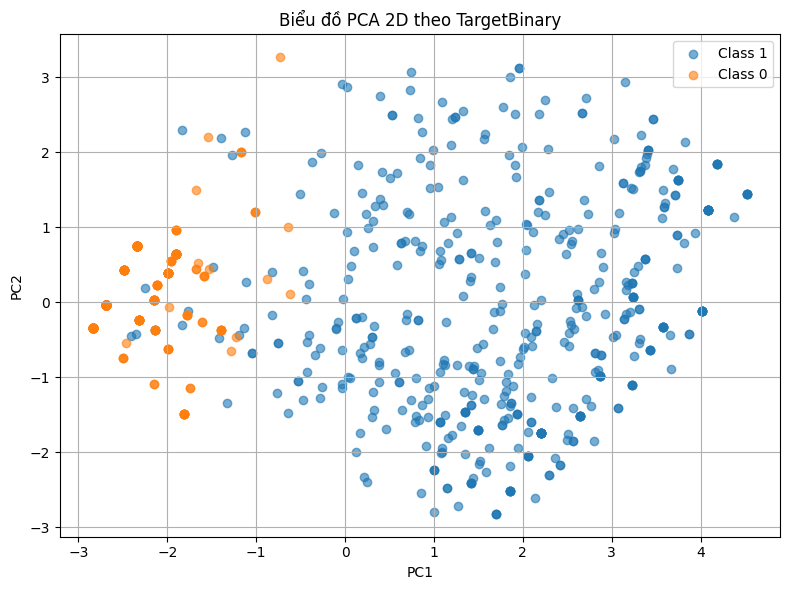

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# Đảm bảo dữ liệu đầu vào tồn tại
df = df_private.copy()
X = df.drop(columns='TargetBinary')
y = df['TargetBinary']

# 1. Chuẩn hóa dữ liệu trước khi PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA 2 thành phần
pca = PCA(n_components=2)
X_pca_result = pca.fit_transform(X_scaled)

# 3. Tạo DataFrame PCA
df_pca = pd.DataFrame(X_pca_result, columns=['PC1', 'PC2'])
df_pca['Target'] = y.reset_index(drop=True)

# 4. Vẽ biểu đồ PCA
plt.figure(figsize=(8,6))
for label in df_pca['Target'].unique():
    subset = df_pca[df_pca['Target'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=f"Class {label}", alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biểu đồ PCA 2D theo TargetBinary")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df_private = df_private.drop(columns=['ChuYLienKet'])
# Bỏ vì đây là thuộc tính có tính chuyên môn cao, phụ huynh dễ đánh giá sai nhưng lại có ảnh hưởng lớn đến kết quả

In [ ]:
df_private = df_private.drop(columns=['GioiTinh'])
# Bỏ vì luôn có tính nhận diện thấp nhất trong tất cả các model


In [ ]:
for i, col in enumerate(df_private.columns):
    print(f"Vị trí {i}: {col}")

Vị trí 0: ChamNoi
Vị trí 1: CungNhac
Vị trí 2: CoLap
Vị trí 3: HanhViLapLai
Vị trí 4: KyNangGiaoTiepSom
Vị trí 5: ChoiLuanPhien
Vị trí 6: PhanUngTenGoi
Vị trí 7: DiNhonChan
Vị trí 8: ChiTro
Vị trí 9: TiepXucMat
Vị trí 10: TargetBinary


In [ ]:
df_private.to_excel("data_private_forModel.xlsx", index=False)

# DECISION TREE

==== Đánh giá mô hình Decision Tree (chạy đơn) ====
Accuracy:     0.965
Recall:       0.949
Specificity:  0.987
Precision:    0.989
F1-score:     0.969
ROC AUC:      0.986
G-Mean:       0.968

=== Độ quan trọng của các đặc trưng (giảm dần) ===
Feature: TiepXucMat, Score: 0.86966
Feature: ChamNoi, Score: 0.08989
Feature: HanhViLapLai, Score: 0.02754
Feature: CungNhac, Score: 0.00859
Feature: KyNangGiaoTiepSom, Score: 0.00298
Feature: PhanUngTenGoi, Score: 0.00067
Feature: ChiTro, Score: 0.00067
Feature: CoLap, Score: 0.00000
Feature: ChoiLuanPhien, Score: 0.00000
Feature: DiNhonChan, Score: 0.00000


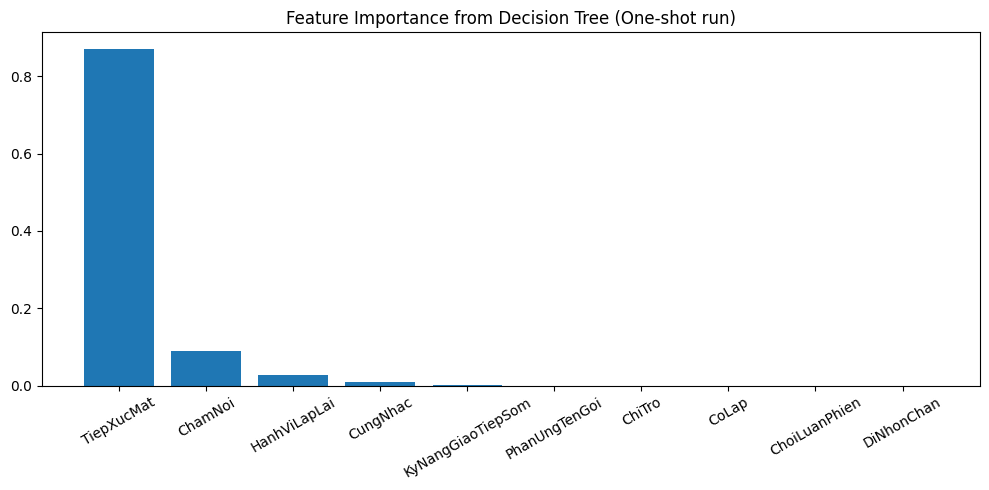

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Tách tập huấn luyện và kiểm tra
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Tạo pipeline
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=7,
    max_leaf_nodes=10,
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=42
)
pipeline = Pipeline(steps=[('imputer', SimpleImputer()), ('model', model)])

# 3. Huấn luyện mô hình
pipeline.fit(X_train, y_train)

# 4. Dự đoán và đánh giá
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Confusion matrix và các độ đo mở rộng
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
gmean = np.sqrt(recall * specificity)

# 5. In kết quả
print("==== Đánh giá mô hình Decision Tree (chạy đơn) ====")
print(f"Accuracy:     {accuracy:.3f}")
print(f"Recall:       {recall:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"ROC AUC:      {roc_auc:.3f}")
print(f"G-Mean:       {gmean:.3f}")

# 6. Tầm quan trọng của đặc trưng
importances = pipeline.named_steps['model'].feature_importances_
feature_names = X.columns
feature_importance = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("\n=== Độ quan trọng của các đặc trưng (giảm dần) ===")
for name, score in feature_importance:
    print(f'Feature: {name}, Score: {score:.5f}')

# 7. Biểu đồ độ quan trọng
sorted_names, sorted_scores = zip(*feature_importance)
plt.figure(figsize=(10, 5))
plt.bar(sorted_names, sorted_scores)
plt.xticks(rotation=30)
plt.title('Feature Importance from Decision Tree (One-shot run)')
plt.tight_layout()
plt.show()


## Drop các thuộc tính đặc trưng phân loại cao: TiepXucMat, ChuYLienKet, ChamNoi, KyNangGiaoTiepSom, PhanUngTenGoi

==== Đánh giá mô hình Decision Tree (chạy đơn) ====
Accuracy:     0.786
Recall:       0.643
Specificity:  0.973
Precision:    0.969
F1-score:     0.773
ROC AUC:      0.853
G-Mean:       0.791

=== Độ quan trọng của các đặc trưng (giảm dần) ===
Feature: CoLap, Score: 0.69762
Feature: DiNhonChan, Score: 0.11098
Feature: CungNhac, Score: 0.10334
Feature: ChoiLuanPhien, Score: 0.04281
Feature: HanhViLapLai, Score: 0.02709
Feature: GioiTinh, Score: 0.01815


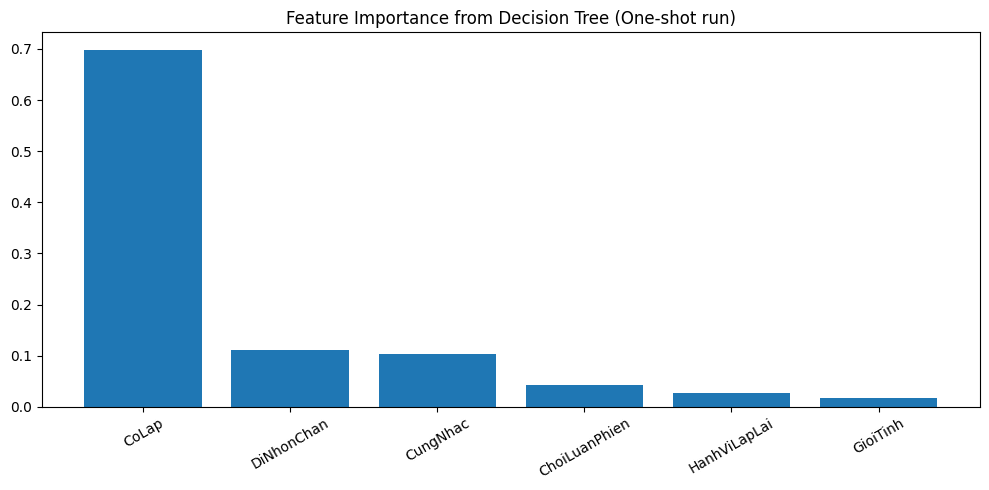

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Tách tập huấn luyện và kiểm tra
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Tạo pipeline
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=7,
    max_leaf_nodes=10,
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=42
)
pipeline = Pipeline(steps=[('imputer', SimpleImputer()), ('model', model)])

# 3. Huấn luyện mô hình
pipeline.fit(X_train, y_train)

# 4. Dự đoán và đánh giá
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Confusion matrix và các độ đo mở rộng
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
gmean = np.sqrt(recall * specificity)

# 5. In kết quả
print("==== Đánh giá mô hình Decision Tree (chạy đơn) ====")
print(f"Accuracy:     {accuracy:.3f}")
print(f"Recall:       {recall:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"ROC AUC:      {roc_auc:.3f}")
print(f"G-Mean:       {gmean:.3f}")

# 6. Tầm quan trọng của đặc trưng
importances = pipeline.named_steps['model'].feature_importances_
feature_names = X.columns
feature_importance = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("\n=== Độ quan trọng của các đặc trưng (giảm dần) ===")
for name, score in feature_importance:
    print(f'Feature: {name}, Score: {score:.5f}')

# 7. Biểu đồ độ quan trọng
sorted_names, sorted_scores = zip(*feature_importance)
plt.figure(figsize=(10, 5))
plt.bar(sorted_names, sorted_scores)
plt.xticks(rotation=30)
plt.title('Feature Importance from Decision Tree (One-shot run)')
plt.tight_layout()
plt.show()


# XGBOOST

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:00:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


==== Đánh giá mô hình XGBoost (chạy đơn) ====
Accuracy:     0.977
Recall:       0.969
Specificity:  0.987
Precision:    0.990
F1-score:     0.979
ROC AUC:      0.997
G-Mean:       0.978

=== Độ quan trọng của các đặc trưng (giảm dần) ===
Feature: TiepXucMat, Score: 0.77369
Feature: ChamNoi, Score: 0.08690
Feature: PhanUngTenGoi, Score: 0.04746
Feature: HanhViLapLai, Score: 0.02563
Feature: CungNhac, Score: 0.02480
Feature: CoLap, Score: 0.01298
Feature: ChiTro, Score: 0.01155
Feature: KyNangGiaoTiepSom, Score: 0.00990
Feature: DiNhonChan, Score: 0.00708
Feature: ChoiLuanPhien, Score: 0.00000


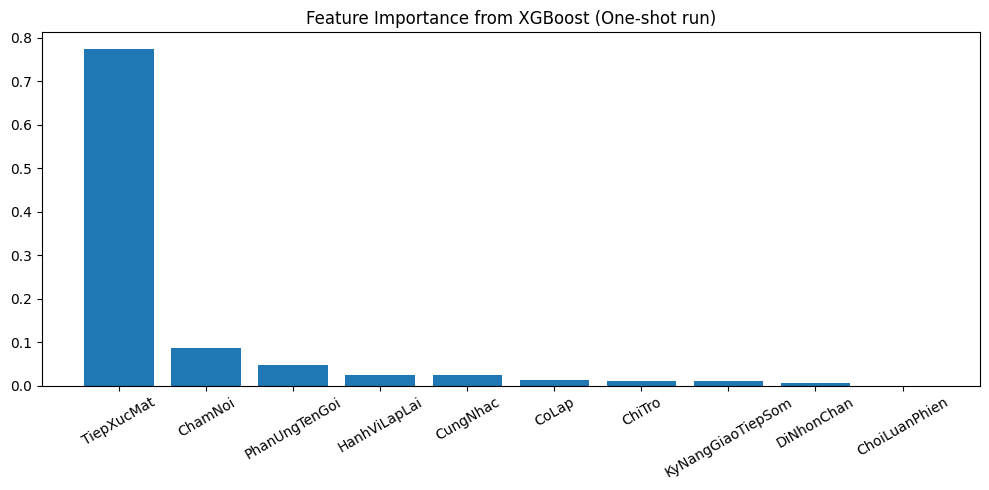

In [ ]:
from xgboost import XGBClassifier
from matplotlib import pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
import numpy as np
import pandas as pd

# 1. Chuẩn bị dữ liệu
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']

# 2. Tách train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Tạo pipeline với XGBoost và SimpleImputer
model = XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer()),
    ('model', model)
])

# 4. Huấn luyện mô hình
pipeline.fit(X_train, y_train)

# 5. Dự đoán và đánh giá
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Các độ đo cơ bản
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Confusion matrix + các độ đo nâng cao
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0
gmean = np.sqrt(recall * specificity)

# 6. In kết quả
print("==== Đánh giá mô hình XGBoost (chạy đơn) ====")
print(f"Accuracy:     {accuracy:.3f}")
print(f"Recall:       {recall:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"ROC AUC:      {roc_auc:.3f}")
print(f"G-Mean:       {gmean:.3f}")

# 7. Tầm quan trọng của đặc trưng
importances = pipeline.named_steps['model'].feature_importances_
feature_names = X.columns
feature_importance = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("\n=== Độ quan trọng của các đặc trưng (giảm dần) ===")
for name, score in feature_importance:
    print(f'Feature: {name}, Score: {score:.5f}')

# 8. Biểu đồ độ quan trọng
sorted_names, sorted_scores = zip(*feature_importance)
plt.figure(figsize=(10, 5))
plt.bar(sorted_names, sorted_scores)
plt.xticks(rotation=30)
plt.title('Feature Importance from XGBoost (One-shot run)')
plt.tight_layout()
plt.show()


## Drop các thuộc tính đặc trưng phân loại cao: TiepXucMat, ChuYLienKet, ChamNoi, KyNangGiaoTiepSom, PhanUngTenGoi

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:18:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


==== Đánh giá mô hình XGBoost (chạy đơn) ====
Accuracy:     0.803
Recall:       0.653
Specificity:  1.000
Precision:    1.000
F1-score:     0.790
ROC AUC:      0.865
G-Mean:       0.808

=== Độ quan trọng của các đặc trưng (giảm dần) ===
Feature: CoLap, Score: 0.38504
Feature: ChoiLuanPhien, Score: 0.38321
Feature: CungNhac, Score: 0.12732
Feature: DiNhonChan, Score: 0.08263
Feature: HanhViLapLai, Score: 0.01408
Feature: GioiTinh, Score: 0.00772


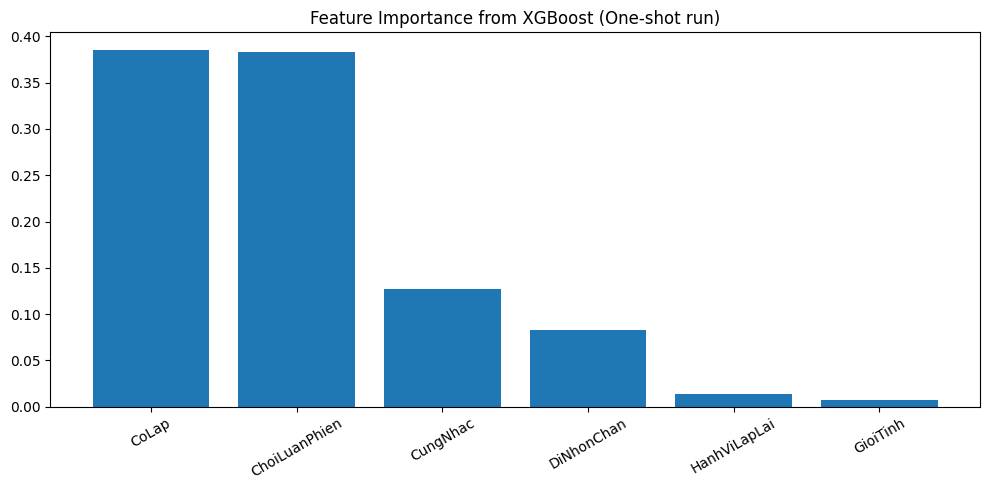

In [ ]:
from xgboost import XGBClassifier
from matplotlib import pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
import numpy as np
import pandas as pd

# 1. Chuẩn bị dữ liệu
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']

# 2. Tách train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Tạo pipeline với XGBoost và SimpleImputer
model = XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer()),
    ('model', model)
])

# 4. Huấn luyện mô hình
pipeline.fit(X_train, y_train)

# 5. Dự đoán và đánh giá
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Các độ đo cơ bản
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Confusion matrix + các độ đo nâng cao
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0
gmean = np.sqrt(recall * specificity)

# 6. In kết quả
print("==== Đánh giá mô hình XGBoost (chạy đơn) ====")
print(f"Accuracy:     {accuracy:.3f}")
print(f"Recall:       {recall:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"ROC AUC:      {roc_auc:.3f}")
print(f"G-Mean:       {gmean:.3f}")

# 7. Tầm quan trọng của đặc trưng
importances = pipeline.named_steps['model'].feature_importances_
feature_names = X.columns
feature_importance = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("\n=== Độ quan trọng của các đặc trưng (giảm dần) ===")
for name, score in feature_importance:
    print(f'Feature: {name}, Score: {score:.5f}')

# 8. Biểu đồ độ quan trọng
sorted_names, sorted_scores = zip(*feature_importance)
plt.figure(figsize=(10, 5))
plt.bar(sorted_names, sorted_scores)
plt.xticks(rotation=30)
plt.title('Feature Importance from XGBoost (One-shot run)')
plt.tight_layout()
plt.show()


https://github.com/apachecn/ml-mastery-zh-pt2/blob/master/docs/ensemble/dynamic-classifier-selection-in-python.md

# OLA

In [ ]:
!sudo pip install deslib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.6/172.6 kB 3.3 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


==== Đánh giá mô hình OLA (chạy đơn) ====
Accuracy:     0.977
Recall:       0.969
Specificity:  0.987
Precision:    0.990
F1-score:     0.979
ROC AUC:      0.992
G-Mean:       0.978

=== Độ quan trọng trung bình của các đặc trưng (từ mô hình hỗ trợ) ===
Feature: TiepXucMat, Score: 0.67558
Feature: ChamNoi, Score: 0.13931
Feature: KyNangGiaoTiepSom, Score: 0.05298
Feature: PhanUngTenGoi, Score: 0.04422
Feature: HanhViLapLai, Score: 0.02342
Feature: CungNhac, Score: 0.02095
Feature: ChiTro, Score: 0.02004
Feature: CoLap, Score: 0.01421
Feature: DiNhonChan, Score: 0.00723
Feature: ChoiLuanPhien, Score: 0.00208


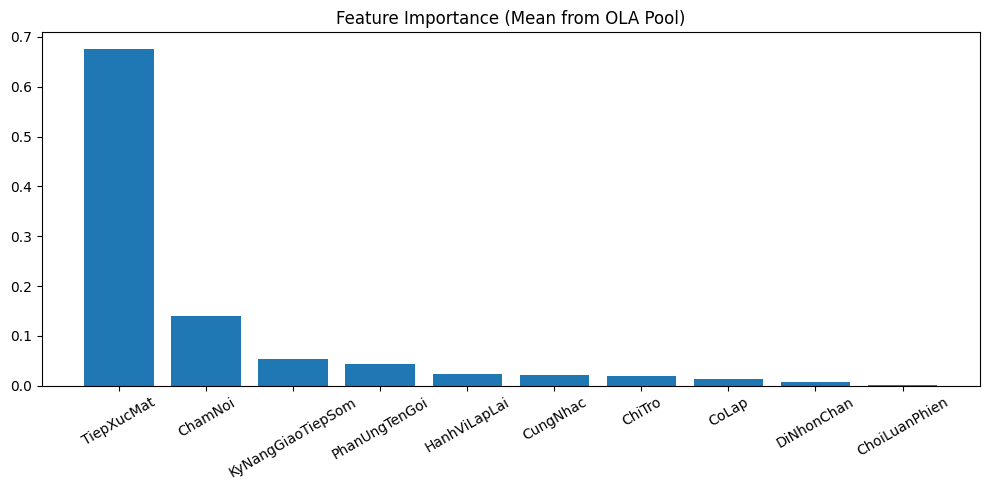

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from deslib.dcs.ola import OLA

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score

# 1. Chuẩn bị dữ liệu
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Tạo pool mô hình với pipeline (SimpleImputer + model)
base_models = [
    DecisionTreeClassifier(max_depth=5, random_state=42),
    KNeighborsClassifier(n_neighbors=5),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42),
    RandomForestClassifier(n_estimators=100, random_state=42)
]

pool_classifiers = []
importances = []

for model in base_models:
    pipeline = Pipeline([
        ('imputer', SimpleImputer()),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    pool_classifiers.append(pipeline)

    # Ghi lại feature importance nếu có
    if hasattr(pipeline.named_steps['model'], "feature_importances_"):
        importances.append(pipeline.named_steps['model'].feature_importances_)

# 3. Huấn luyện OLA trên các mô hình đã train
# Chỉ dùng các mô hình huấn luyện với PCA
ola_pool = [clf.named_steps['model'] for clf in pool_classifiers if 'model' in clf.named_steps]
ola = OLA(pool_classifiers=ola_pool)
ola.fit(X_train, y_train)

# 4. Dự đoán & đánh giá
y_pred = ola.predict(X_test)

# Dự đoán xác suất trung bình nếu có
proba_list = [
    clf.predict_proba(X_test)[:, 1]
    for clf in pool_classifiers if hasattr(clf, "predict_proba")
]
y_prob = np.mean(proba_list, axis=0)

# 5. Tính các độ đo
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0
gmean = np.sqrt(recall * specificity)

# 6. In kết quả
print("==== Đánh giá mô hình OLA (chạy đơn) ====")
print(f"Accuracy:     {accuracy:.3f}")
print(f"Recall:       {recall:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"ROC AUC:      {roc_auc:.3f}")
print(f"G-Mean:       {gmean:.3f}")

# 7. Feature Importance (trung bình nếu có)
if importances:
    mean_importance = np.mean(importances, axis=0)
    feature_names = X.columns
    feature_importance = sorted(zip(feature_names, mean_importance), key=lambda x: x[1], reverse=True)

    print("\n=== Độ quan trọng trung bình của các đặc trưng (từ mô hình hỗ trợ) ===")
    for name, score in feature_importance:
        print(f'Feature: {name}, Score: {score:.5f}')

    # Vẽ biểu đồ
    sorted_names, sorted_scores = zip(*feature_importance)
    plt.figure(figsize=(10, 5))
    plt.bar(sorted_names, sorted_scores)
    plt.xticks(rotation=30)
    plt.title('Feature Importance (Mean from OLA Pool)')
    plt.tight_layout()
    plt.show()
else:
    print("❗ Không có mô hình nào trong pool hỗ trợ .feature_importances_.")


## Drop các thuộc tính đặc trưng phân loại cao: TiepXucMat, ChuYLienKet, ChamNoi, KyNangGiaoTiepSom, PhanUngTenGoi

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Si

==== Đánh giá mô hình OLA (chạy đơn) ====
Accuracy:     0.798
Recall:       0.643
Specificity:  1.000
Precision:    1.000
F1-score:     0.783
ROC AUC:      0.834
G-Mean:       0.802

=== Độ quan trọng trung bình của các đặc trưng (từ mô hình hỗ trợ) ===
Feature: CoLap, Score: 0.48291
Feature: ChoiLuanPhien, Score: 0.20929
Feature: CungNhac, Score: 0.12980
Feature: DiNhonChan, Score: 0.10655
Feature: HanhViLapLai, Score: 0.04732
Feature: GioiTinh, Score: 0.02413


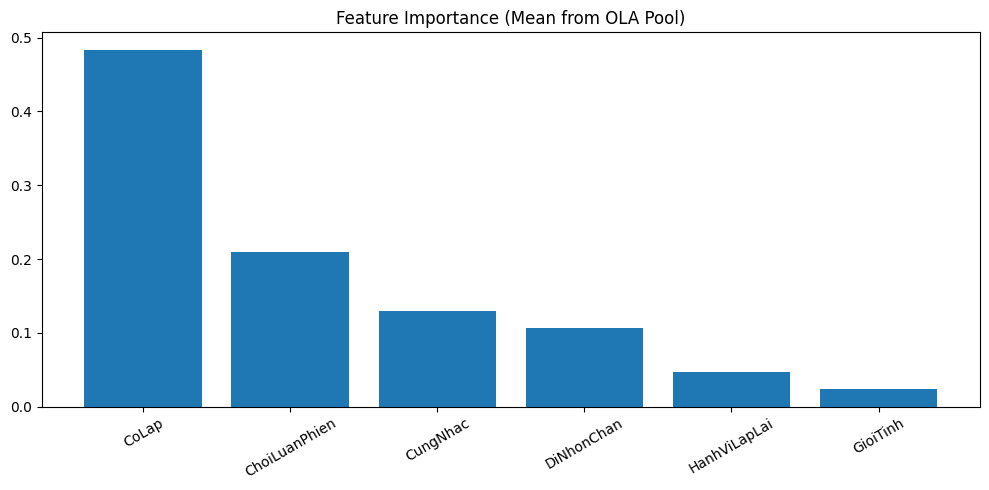

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from deslib.dcs.ola import OLA

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score

# 1. Chuẩn bị dữ liệu
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Tạo pool mô hình với pipeline (SimpleImputer + model)
base_models = [
    DecisionTreeClassifier(max_depth=5, random_state=42),
    KNeighborsClassifier(n_neighbors=5),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42),
    RandomForestClassifier(n_estimators=100, random_state=42)
]

pool_classifiers = []
importances = []

for model in base_models:
    pipeline = Pipeline([
        ('imputer', SimpleImputer()),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    pool_classifiers.append(pipeline)

    # Ghi lại feature importance nếu có
    if hasattr(pipeline.named_steps['model'], "feature_importances_"):
        importances.append(pipeline.named_steps['model'].feature_importances_)

# 3. Huấn luyện OLA trên các mô hình đã train
ola = OLA(pool_classifiers=pool_classifiers)
ola.fit(X_train, y_train)

# 4. Dự đoán & đánh giá
y_pred = ola.predict(X_test)

# Dự đoán xác suất trung bình nếu có
proba_list = [
    clf.predict_proba(X_test)[:, 1]
    for clf in pool_classifiers if hasattr(clf, "predict_proba")
]
y_prob = np.mean(proba_list, axis=0)

# 5. Tính các độ đo
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0
gmean = np.sqrt(recall * specificity)

# 6. In kết quả
print("==== Đánh giá mô hình OLA (chạy đơn) ====")
print(f"Accuracy:     {accuracy:.3f}")
print(f"Recall:       {recall:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"ROC AUC:      {roc_auc:.3f}")
print(f"G-Mean:       {gmean:.3f}")

# 7. Feature Importance (trung bình nếu có)
if importances:
    mean_importance = np.mean(importances, axis=0)
    feature_names = X.columns
    feature_importance = sorted(zip(feature_names, mean_importance), key=lambda x: x[1], reverse=True)

    print("\n=== Độ quan trọng trung bình của các đặc trưng (từ mô hình hỗ trợ) ===")
    for name, score in feature_importance:
        print(f'Feature: {name}, Score: {score:.5f}')

    # Vẽ biểu đồ
    sorted_names, sorted_scores = zip(*feature_importance)
    plt.figure(figsize=(10, 5))
    plt.bar(sorted_names, sorted_scores)
    plt.xticks(rotation=30)
    plt.title('Feature Importance (Mean from OLA Pool)')
    plt.tight_layout()
    plt.show()
else:
    print("❗ Không có mô hình nào trong pool hỗ trợ .feature_importances_.")


# CatBoost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.9 MB/s eta 0:00:00


==== Đánh giá mô hình CatBoost (chạy đơn) ====
Accuracy :     0.983 – Độ chính xác tổng thể
Recall:       0.980 – Độ nhạy / độ bao phủ của lớp dương
Specificity:  0.987 – Độ đặc hiệu
Precision:    0.990 – Độ chính xác của dự đoán dương
F1-score:     0.985 – Hòa hợp Precision và Recall
ROC AUC:      0.997 – Diện tích dưới đường cong ROC
G-Mean:       0.983 – Trung bình hình học giữa độ nhạy và độ đặc hiệu

=== Độ quan trọng của các đặc trưng (giảm dần) ===
Feature: TiepXucMat, Score: 46.01522
Feature: ChamNoi, Score: 14.76054
Feature: KyNangGiaoTiepSom, Score: 10.28550
Feature: PhanUngTenGoi, Score: 8.93815
Feature: CungNhac, Score: 7.03914
Feature: HanhViLapLai, Score: 4.47001
Feature: ChiTro, Score: 3.32285
Feature: DiNhonChan, Score: 2.41812
Feature: ChoiLuanPhien, Score: 2.01546
Feature: CoLap, Score: 0.73500


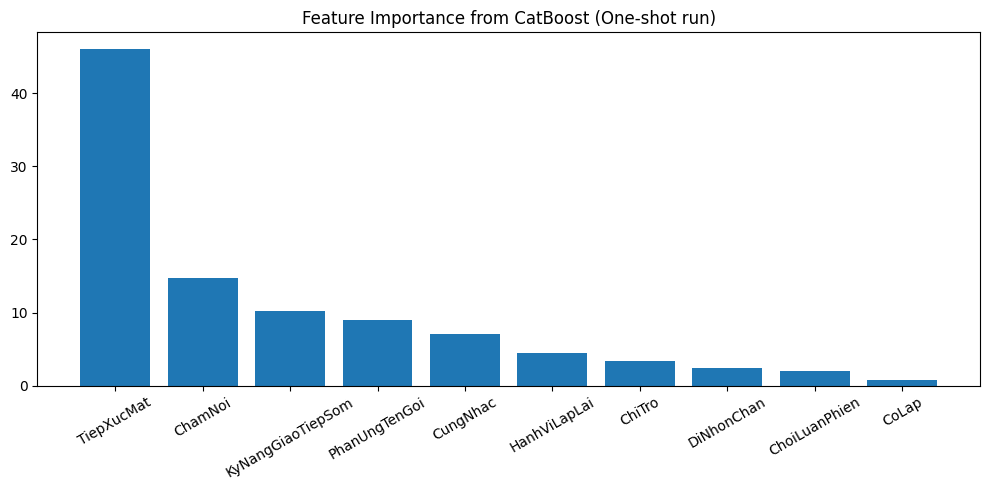

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Tách dữ liệu
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Khởi tạo CatBoost
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.01,
    l2_leaf_reg=5,
    bootstrap_type='Bernoulli',
    subsample=0.7,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=False
)

# 3. Huấn luyện mô hình
model.fit(X_train, y_train)

# 4. Dự đoán
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 5. Tính các độ đo
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Confusion matrix và các độ đo dẫn xuất
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) else 0  # giống recall
specificity = tn / (tn + fp) if (tn + fp) else 0
gmean = np.sqrt(sensitivity * specificity)

# 6. In kết quả
print("==== Đánh giá mô hình CatBoost (chạy đơn) ====")
print(f"Accuracy :     {accuracy:.3f} – Độ chính xác tổng thể")
print(f"Recall:       {recall:.3f} – Độ nhạy / độ bao phủ của lớp dương")
print(f"Specificity:  {specificity:.3f} – Độ đặc hiệu")
print(f"Precision:    {precision:.3f} – Độ chính xác của dự đoán dương")
print(f"F1-score:     {f1:.3f} – Hòa hợp Precision và Recall")
print(f"ROC AUC:      {roc_auc:.3f} – Diện tích dưới đường cong ROC")
print(f"G-Mean:       {gmean:.3f} – Trung bình hình học giữa độ nhạy và độ đặc hiệu")

# 7. Độ quan trọng đặc trưng
importances = model.get_feature_importance()
feature_names = X.columns
feature_importance = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("\n=== Độ quan trọng của các đặc trưng (giảm dần) ===")
for name, score in feature_importance:
    print(f'Feature: {name}, Score: {score:.5f}')

# 8. Biểu đồ
sorted_names, sorted_scores = zip(*feature_importance)
plt.figure(figsize=(10, 5))
plt.bar(sorted_names, sorted_scores)
plt.xticks(rotation=30)
plt.title('Feature Importance from CatBoost (One-shot run)')
plt.tight_layout()
plt.show()


## Drop các thuộc tính đặc trưng phân loại cao: TiepXucMat, ChuYLienKet, ChamNoi, KyNangGiaoTiepSom, PhanUngTenGoi

==== Đánh giá mô hình CatBoost (chạy đơn) ====
Accuracy :     0.803 – Độ chính xác tổng thể
Recall:       0.653 – Độ nhạy / độ bao phủ của lớp dương
Specificity:  1.000 – Độ đặc hiệu
Precision:    1.000 – Độ chính xác của dự đoán dương
F1-score:     0.790 – Hòa hợp Precision và Recall
ROC AUC:      0.876 – Diện tích dưới đường cong ROC
G-Mean:       0.808 – Trung bình hình học giữa độ nhạy và độ đặc hiệu

=== Độ quan trọng của các đặc trưng (giảm dần) ===
Feature: CoLap, Score: 34.75988
Feature: ChoiLuanPhien, Score: 29.50643
Feature: CungNhac, Score: 14.99183
Feature: DiNhonChan, Score: 12.25349
Feature: HanhViLapLai, Score: 4.48217
Feature: GioiTinh, Score: 4.00619


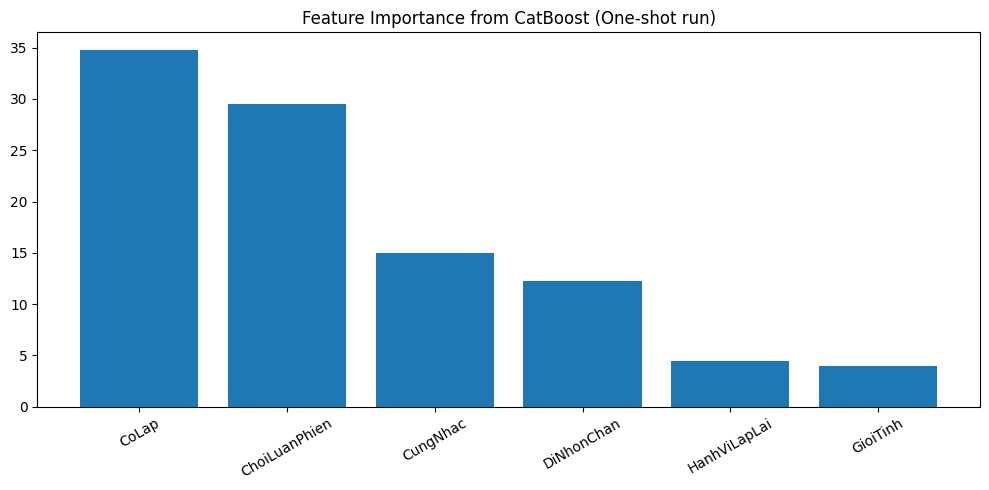

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Tách dữ liệu
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Khởi tạo CatBoost
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.01,
    l2_leaf_reg=5,
    bootstrap_type='Bernoulli',
    subsample=0.7,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=False
)

# 3. Huấn luyện mô hình
model.fit(X_train, y_train)

# 4. Dự đoán
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 5. Tính các độ đo
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Confusion matrix và các độ đo dẫn xuất
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) else 0  # giống recall
specificity = tn / (tn + fp) if (tn + fp) else 0
gmean = np.sqrt(sensitivity * specificity)

# 6. In kết quả
print("==== Đánh giá mô hình CatBoost (chạy đơn) ====")
print(f"Accuracy :     {accuracy:.3f} – Độ chính xác tổng thể")
print(f"Recall:       {recall:.3f} – Độ nhạy / độ bao phủ của lớp dương")
print(f"Specificity:  {specificity:.3f} – Độ đặc hiệu")
print(f"Precision:    {precision:.3f} – Độ chính xác của dự đoán dương")
print(f"F1-score:     {f1:.3f} – Hòa hợp Precision và Recall")
print(f"ROC AUC:      {roc_auc:.3f} – Diện tích dưới đường cong ROC")
print(f"G-Mean:       {gmean:.3f} – Trung bình hình học giữa độ nhạy và độ đặc hiệu")

# 7. Độ quan trọng đặc trưng
importances = model.get_feature_importance()
feature_names = X.columns
feature_importance = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("\n=== Độ quan trọng của các đặc trưng (giảm dần) ===")
for name, score in feature_importance:
    print(f'Feature: {name}, Score: {score:.5f}')

# 8. Biểu đồ
sorted_names, sorted_scores = zip(*feature_importance)
plt.figure(figsize=(10, 5))
plt.bar(sorted_names, sorted_scores)
plt.xticks(rotation=30)
plt.title('Feature Importance from CatBoost (One-shot run)')
plt.tight_layout()
plt.show()


# Cross Validation Chung

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
from sklearn.base import clone
import numpy as np
import pandas as pd

def evaluate_model_crossval(model, X, y, model_name="Model", k_folds=5, is_ola=False):
    kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if is_ola:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_prob = np.mean([
                clf.predict_proba(X_test)[:, 1]
                for clf in model.pool_classifiers if hasattr(clf, "predict_proba")
            ], axis=0)
        else:
            fitted_model = clone(model)
            fitted_model.fit(X_train, y_train)
            y_pred = fitted_model.predict(X_test)
            y_prob = (
                fitted_model.predict_proba(X_test)[:, 1]
                if hasattr(fitted_model, "predict_proba") else y_pred
            )

        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) else 0
        gmean = np.sqrt(recall * specificity)

        fold_results.append({
            "Fold": fold,
            "Accuracy": round(accuracy, 3),
            "Recall": round(recall, 3),
            "Specificity": round(specificity, 3),
            "Precision": round(precision, 3),
            "F1-score": round(f1, 3),
            "ROC AUC": round(roc_auc, 3),
            "G-Mean": round(gmean, 3)
        })

    avg_row = {"Fold": "Trung bình"}
    for key in fold_results[0].keys():
        if key != "Fold":
            avg_row[key] = round(np.mean([r[key] for r in fold_results]), 3)
    fold_results.append(avg_row)

    df = pd.DataFrame(fold_results)
    print(f"\n==== Kết quả Cross-Validation cho {model_name} ====")
    print(df.to_string(index=False))
    print("\n=== Trung bình các độ đo ===")
    print(df_cv_results.mean(numeric_only=True).round(3))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from deslib.dcs.ola import OLA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Dữ liệu
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']

# === Decision Tree ===
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
evaluate_model_crossval(dt_model, X, y, model_name="Decision Tree")

# === XGBoost ===
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
evaluate_model_crossval(xgb_model, X, y, model_name="XGBoost")


# === OLA ===
base_models = [
    Pipeline([('imputer', SimpleImputer()), ('model', DecisionTreeClassifier(max_depth=5))]),
    Pipeline([('imputer', SimpleImputer()), ('model', RandomForestClassifier(n_estimators=100))]),
    Pipeline([('imputer', SimpleImputer()), ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))])
]

# Fit từng pipeline trong pool
for pipe in base_models:
    pipe.fit(X, y)

ola_model = OLA(pool_classifiers=base_models)
ola_model.fit(X, y)
evaluate_model_crossval(ola_model, X, y, model_name="OLA (with pool)", is_ola=True)

# === CatBoost ===
catboost_model = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.01,
                                    verbose=0, random_state=42, eval_metric='Accuracy')
evaluate_model_crossval(catboost_model, X, y, model_name="CatBoost")


==== Kết quả Cross-Validation cho Decision Tree ====
      Fold  Accuracy  Recall  Specificity  Precision  F1-score  ROC AUC  G-Mean
         1     0.870   0.920        0.820      0.836     0.876    0.903   0.869
         2     0.850   0.760        0.940      0.927     0.835    0.867   0.845
         3     0.840   0.840        0.840      0.840     0.840    0.833   0.840
         4     0.810   0.880        0.740      0.772     0.822    0.912   0.807
         5     0.790   0.740        0.840      0.822     0.779    0.799   0.788
Trung bình     0.832   0.828        0.836      0.839     0.830    0.863   0.830


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:19:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:19:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:19:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:19:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:19:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


==== Kết quả Cross-Validation cho XGBoost ====
      Fold  Accuracy  Recall  Specificity  Precision  F1-score  ROC AUC  G-Mean
         1      0.91   0.920        0.900      0.902     0.911    0.956   0.910
         2      0.95   0.940        0.960      0.959     0.949    0.988   0.950
         3      0.90   0.900        0.900      0.900     0.900    0.959   0.900
         4      0.90   0.960        0.840      0.857     0.906    0.958   0.898
         5      0.84   0.800        0.880      0.870     0.833    0.945   0.839
Trung bình      0.90   0.904        0.896      0.898     0.900    0.961   0.899


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:19:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have vali


==== Kết quả Cross-Validation cho OLA (with pool) ====
      Fold  Accuracy  Recall  Specificity  Precision  F1-score  ROC AUC  G-Mean
         1      0.97   0.940        1.000      1.000     0.969      1.0   0.970
         2      0.99   0.980        1.000      1.000     0.990      1.0   0.990
         3      1.00   1.000        1.000      1.000     1.000      1.0   1.000
         4      0.98   0.980        0.980      0.980     0.980      1.0   0.980
         5      0.96   0.920        1.000      1.000     0.958      1.0   0.959
Trung bình      0.98   0.964        0.996      0.996     0.979      1.0   0.980

==== Kết quả Cross-Validation cho CatBoost ====
      Fold  Accuracy  Recall  Specificity  Precision  F1-score  ROC AUC  G-Mean
         1     0.890   0.900        0.880      0.882     0.891    0.963   0.890
         2     0.960   0.920        1.000      1.000     0.958    0.995   0.959
         3     0.910   0.900        0.920      0.918     0.909    0.980   0.910
         4     

# CẢI TIẾN OLA

**TỔNG KẾT:** Kiểm soát ảnh hưởng đặc trưng mạnh (TiepXucMat) trong OLA bằng PCA.
1. Vấn đề:
Trong nhiều mô hình học máy, một số đặc trưng như TiepXucMat có thể có ảnh hưởng quá mạnh (độ quan trọng cao) dẫn đến:
- Overfitting vào đặc trưng đó,
- Giảm khả năng tổng quát trên dữ liệu thực tế,
- Không ổn định nếu đặc trưng này có thể nhiễu hoặc không đầy đủ trong tương lai.
2.1. Giải pháp 1 – Thiết kế Pool đa dạng (không dùng PCA):
- Chiến lược:
-+ Tạo 2 nhóm mô hình trong pool của OLA:
-+ Nhóm 1: Sử dụng toàn bộ đặc trưng (bao gồm TiepXucMat).
-+ Nhóm 2: Loại bỏ TiepXucMat khỏi dữ liệu đầu vào (sử dụng ColumnDropper hoặc .drop(...)).
- Tác dụng:
-+ OLA chọn mô hình phù hợp tùy theo từng mẫu.
-+ Nếu TiepXucMat thực sự không mang lại lợi ích ở một số vùng dữ liệu, OLA sẽ chọn mô hình không dùng nó.
-+ Điều này giúp giảm sự phụ thuộc cứng vào một đặc trưng mạnh.
2.2. Giải pháp 2 – Sử dụng PCA kết hợp với OLA. Vì sao PCA giúp giảm ảnh hưởng TiepXucMat?
- PCA chuyển toàn bộ đặc trưng về không gian mới (PC space), nơi mỗi PC là tổ hợp tuyến tính của tất cả đặc trưng gốc.
- Điều này giúp:
-+ Phân tán ảnh hưởng của TiepXucMat sang nhiều thành phần.
-+ Tránh để một mô hình học "quá tập trung" vào một feature cụ thể.
3. Tiền xử lý:
- Áp dụng StandardScaler rồi PCA (giữ 95% phương sai).
- Huấn luyện OLA trên các mô hình train bằng không gian PCA.
- Tính độ quan trọng đặc trưng:
-+ Tính feature_importance trung bình từ các mô hình hỗ trợ trong pool (trong không gian PCA).
-+ Chiếu ngược các importance từ PC space về không gian gốc:
-+ Kết quả là độ quan trọng tương đối của từng cột gốc sau khi đã "giảm ảnh hưởng cứng" bằng PCA.

### PCA + OLA ĐƠN

Huấn luyện một hệ thống phân loại sử dụng PCA để giảm chiều dữ
liệu, sau đo kết hợp nhiều mô hình với kỹ thuat chọn động theo khu vực (OLA - Online Local Accuracy),
và đánh giá hiệu quả phân loại.

### PCA + OLA + kiểm soát đặc trưng --> Chọn Model này với 10 features sau

In [ ]:
# Liệt kê tên các cột
print(df_private.columns.tolist())

['ChamNoi', 'CungNhac', 'CoLap', 'HanhViLapLai', 'KyNangGiaoTiepSom', 'ChoiLuanPhien', 'PhanUngTenGoi', 'DiNhonChan', 'ChiTro', 'TiepXucMat', 'TargetBinary']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from deslib.dcs.ola import OLA

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score

# === 1. Tách dữ liệu từ df_private gốc ===
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']
feature_names = X.columns.tolist()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# === 2. Chuẩn hóa + PCA ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# === 3. ColumnDropper hỗ trợ DataFrame và ndarray ===
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns, feature_names=None):
        self.columns = columns
        self.feature_names = feature_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.drop(columns=self.columns, errors='ignore')
        elif isinstance(X, np.ndarray):
            if self.feature_names is None or X.shape[1] != len(self.feature_names):
                raise ValueError("ColumnDropper: mismatch or missing feature names.")
            df = pd.DataFrame(X, columns=self.feature_names)
            return df.drop(columns=self.columns, errors='ignore').values
        else:
            raise ValueError("Unsupported input type for ColumnDropper.")

# === 4. Tạo pool model ===
pool_classifiers = []

# Group 1: mô hình PCA
pca_models = [
    DecisionTreeClassifier(max_depth=5, random_state=42),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42)
]
for model in pca_models:
    model.fit(X_train_pca, y_train)
    pool_classifiers.append(model)

# Group 2: model loại bỏ TiepXucMat
dropper = ColumnDropper(columns=['TiepXucMat'], feature_names=feature_names)
reduced_pipe = Pipeline([
    ('drop', dropper),
    ('imputer', SimpleImputer()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
reduced_pipe.fit(X_train_raw, y_train)
pool_classifiers.append(reduced_pipe)

# Group 3: model full raw
full_pipe = Pipeline([
    ('imputer', SimpleImputer()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
full_pipe.fit(X_train_raw, y_train)
pool_classifiers.append(full_pipe)

# === 5. Huấn luyện OLA chỉ với mô hình PCA ===
ola_pool = [clf for clf in pool_classifiers if not isinstance(clf, Pipeline)]
ola = OLA(pool_classifiers=ola_pool)
ola.fit(X_train_pca, y_train)

# === 6. Dự đoán OLA ===
y_pred = ola.predict(X_test_pca)

# === 7. Tính xác suất dự đoán ensemble
proba_list = []
for clf in pool_classifiers:
    try:
        if isinstance(clf, Pipeline):
            proba = clf.predict_proba(X_test_raw)[:, 1]
        else:
            proba = clf.predict_proba(X_test_pca)[:, 1]
        proba_list.append(proba)
    except Exception as e:
        print(f"[WARN] Bỏ qua model do lỗi: {e}")

y_prob = np.mean(proba_list, axis=0)

# === 8. Đánh giá
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0
gmean = np.sqrt(recall * specificity)

# === 9. In kết quả
results = {
    "Accuracy": round(accuracy, 3),
    "Recall": round(recall, 3),
    "Precision": round(precision, 3),
    "F1-score": round(f1, 3),
    "ROC AUC": round(roc_auc, 3),
    "Specificity": round(specificity, 3),
    "G-Mean": round(gmean, 3)
}

print("=== Kết quả PCA + OLA với kiểm soát TiepXucMat ===")
for k, v in results.items():
    print(f"{k:12}: {v}")


=== Kết quả PCA + OLA với kiểm soát TiepXucMat ===
Accuracy    : 0.977
Recall      : 0.969
Precision   : 0.99
F1-score    : 0.979
ROC AUC     : 0.983
Specificity : 0.987
G-Mean      : 0.978


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



== Độ ảnh hưởng tổng hợp của các cột gốc trong PCA:
CoLap                2.545422
ChoiLuanPhien        2.510236
KyNangGiaoTiepSom    2.415590
CungNhac             2.404217
ChiTro               2.392919
HanhViLapLai         2.319694
ChamNoi              2.164961
PhanUngTenGoi        2.034019
DiNhonChan           1.896599
TiepXucMat           1.622900
dtype: float64


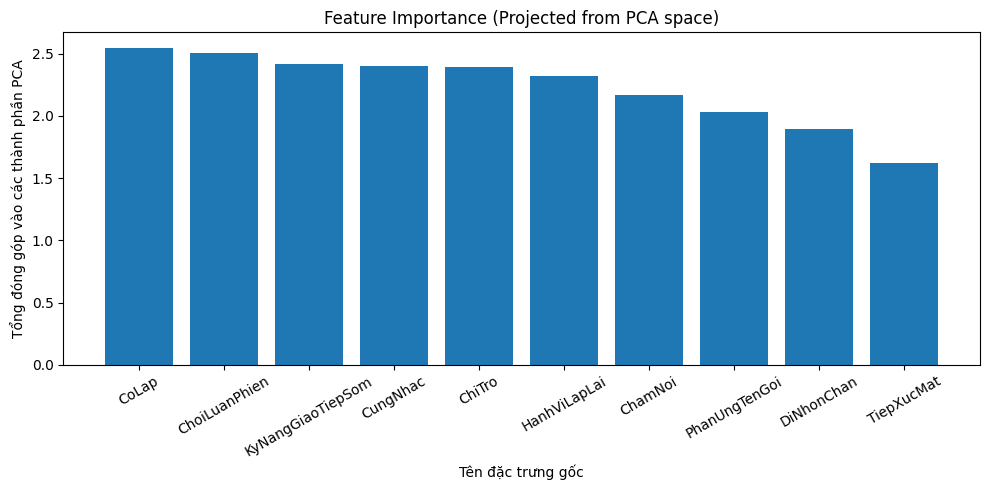

In [ ]:
# Lấy thành phần PCA
pca_components = pd.DataFrame(
    np.abs(pca.components_),
    columns=feature_names
)

# Tính tổng độ đóng góp của mỗi cột gốc vào tất cả các thành phần chính
pca_feature_influence = pca_components.sum(axis=0).sort_values(ascending=False)

print("\n== Độ ảnh hưởng tổng hợp của các cột gốc trong PCA:")
print(pca_feature_influence)

# Lấy thành phần PCA
pca_components = pd.DataFrame(
    np.abs(pca.components_),
    columns=feature_names
)

# Tính tổng độ đóng góp của mỗi đặc trưng gốc
pca_feature_influence = pca_components.sum(axis=0).sort_values(ascending=False)

# Trực quan hóa
names = pca_feature_influence.index.tolist()
scores = pca_feature_influence.values.tolist()

plt.figure(figsize=(10, 5))
plt.bar(names, scores)
plt.xticks(rotation=30)
plt.title('Feature Importance (Projected from PCA space)')
plt.xlabel('Tên đặc trưng gốc')
plt.ylabel('Tổng đóng góp vào các thành phần PCA')
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.metrics import geometric_mean_score

# --- 1. Chuẩn bị dữ liệu ---
X = df_private.drop(columns='TargetBinary')
y = df_private['TargetBinary']
feature_names = X.columns.tolist()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

# --- 2. Vòng lặp Cross-validation ---
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Tiền xử lý: scale + PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Pool các mô hình
    pool_classifiers = []

    # Group 1: PCA models
    pca_models = [
        DecisionTreeClassifier(max_depth=5, random_state=42),
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42)
    ]
    for model in pca_models:
        model.fit(X_train_pca, y_train)
        pool_classifiers.append(model)

    # Group 2: Raw without TiepXucMat
    dropper = ColumnDropper(columns=['Feature0'], feature_names=feature_names)
    reduced_pipe = Pipeline([
        ('drop', dropper),
        ('imputer', SimpleImputer()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    reduced_pipe.fit(X_train_raw, y_train)
    pool_classifiers.append(reduced_pipe)

    # Group 3: Full raw
    full_pipe = Pipeline([
        ('imputer', SimpleImputer()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
    full_pipe.fit(X_train_raw, y_train)
    pool_classifiers.append(full_pipe)

    # Huấn luyện OLA
    ola_pool = [clf for clf in pool_classifiers if not isinstance(clf, Pipeline)]
    ola = OLA(pool_classifiers=ola_pool)
    ola.fit(X_train_pca, y_train)
    y_pred = ola.predict(X_test_pca)

    # Tính xác suất từ toàn bộ mô hình
    proba_list = []
    for clf in pool_classifiers:
        try:
            if isinstance(clf, Pipeline):
                proba = clf.predict_proba(X_test_raw)[:, 1]
            else:
                proba = clf.predict_proba(X_test_pca)[:, 1]
            proba_list.append(proba)
        except Exception:
            continue

    y_prob = np.mean(proba_list, axis=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0
    gmean = np.sqrt(recall_score(y_test, y_pred) * specificity)

    metrics = {
        "Fold": fold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Specificity": specificity,
        "Precision": precision_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "G-Mean": gmean
    }
    cv_results.append(metrics)

# --- 3. Hiển thị kết quả sau khi hoàn tất tất cả folds ---
# Sau vòng lặp for, khi df_cv_results đã được tạo:
df_cv_results = pd.DataFrame(cv_results)

# Tính dòng trung bình
average_row = df_cv_results.mean(numeric_only=True)
average_row['Fold'] = 'Trung bình'

# Ghép vào DataFrame kết quả
df_cv_results = pd.concat([df_cv_results, pd.DataFrame([average_row])], ignore_index=True)

# Làm tròn hiển thị
df_cv_results = df_cv_results.round(3)
print("==== Kết quả Cross-Validation cho PCA + OLA + kiểm soát đặc trưng ====")
print(df_cv_results.to_string(index=False))


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator.

==== Kết quả Cross-Validation cho PCA + OLA + kiểm soát đặc trưng ====
      Fold  Accuracy  Recall  Specificity  Precision  F1-score  ROC AUC  G-Mean
         1     0.971   0.969        0.973      0.979     0.974    0.994   0.971
         2     0.977   0.980        0.973      0.980     0.980    0.999   0.976
         3     0.977   0.969        0.987      0.990     0.979    0.992   0.978
         4     0.983   0.980        0.987      0.990     0.985    0.999   0.983
         5     0.965   0.938        1.000      1.000     0.968    0.985   0.969
Trung bình     0.975   0.967        0.984      0.988     0.977    0.994   0.976


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
<ipython-input-216-d649517d9e2d>:100: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Trung bình' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  average_row['Fold'] = 'Trung bình'
